# 🦟 Previsão de Surtos de Dengue — Ribeirão Preto, SP

Este notebook implementa um pipeline completo de aprendizado de máquina para **prever surtos de dengue com até 16 semanas de antecedência**.

**Modelos utilizados:**
- Random Forest (Baseline e Otimizado com GridSearch)
- LSTM implementado do zero com NumPy
- LSTM implementado com PyTorch

**Etapas do pipeline:**
1. Configuração do ambiente
2. Carregamento e exploração dos dados (EDA)
3. Engenharia de features
4. Modelagem com Random Forest
5. Modelagem com LSTM (NumPy)
6. Modelagem com LSTM (PyTorch)
7. Comparação final dos modelos

---
## 1. Configuração do Ambiente

Importamos todas as bibliotecas necessárias e configuramos os parâmetros visuais padrão dos gráficos.

- **NumPy / Pandas**: manipulação de dados tabulares e séries temporais
- **Matplotlib / Seaborn**: visualizações estáticas
- **scikit-learn**: pré-processamento, modelos clássicos e métricas
- **PyTorch**: construção e treinamento do modelo LSTM profundo
- **gdown / zipfile**: download e extração do dataset do Google Drive

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from io import StringIO
from pathlib import Path
import logging
import zipfile
import gdown
import os
import sys
import openpyxl
from scipy import stats
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
print(f"Versão do Pandas  : {pd.__version__}")
print(f"Versão do NumPy   : {np.__version__}")
print(f"Versão do Seaborn : {sns.__version__}")
print(f"Versão do PyTorch : {torch.__version__}")
print(f"Dispositivo CUDA  : {'disponível ✓' if torch.cuda.is_available() else 'não disponível — usando CPU'}")

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)

Versão do Pandas  : 3.0.3
Versão do NumPy   : 2.5.0
Versão do Seaborn : 0.13.2
Versão do PyTorch : 2.12.1+cu126
Dispositivo CUDA  : disponível ✓


In [2]:
# Dispositivo de processamento (GPU se disponível)
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paleta de cores do projeto
PALETA_CORES = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#264653']
PALETA = sns.color_palette(PALETA_CORES)

# Configuração global dos gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.color': '#b0b0b0',
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.edgecolor': '#555555',
    'axes.linewidth': 1.0,
})

---
## 2. Carregamento dos Dados

O dataset é baixado automaticamente do Google Drive. Ele contém dados semanais de:
- **Casos de dengue** (variável alvo)
- **Variáveis climáticas**: temperatura, umidade, chuva, ponto de orvalho etc.
- **Índices de teleconexão climática**: ONI, AMM, AAO
- **Variáveis epidemiológicas e espaciais**: distribuição por sub-regiões

Após o download, os dados são organizados por data e a frequência temporal é inferida automaticamente.

In [3]:
# Criação dos diretórios de trabalho
CAMINHO_BASE = Path('../data/dataset')
CAMINHO_FIGURAS = Path('../data/figures')

diretorios = [
    CAMINHO_BASE,
    CAMINHO_BASE / 'processado',
    CAMINHO_BASE / 'bruto',
    CAMINHO_FIGURAS / 'meses' / '4',
    CAMINHO_FIGURAS / 'meses' / '8',
    CAMINHO_FIGURAS / 'meses' / '12',
    CAMINHO_FIGURAS / 'meses' / '16',
]

for caminho in diretorios:
    caminho.mkdir(parents=True, exist_ok=True)

CAMINHO_DADOS_BRUTOS = Path('../data/dataset/bruto/')
CAMINHO_DADOS_PROCESSADOS = Path('../data/dataset/processado/')

In [4]:
# Download do dataset
id_arquivo = '1FGMMv8R3xYxJtHj5yV6N1k5o4RupZbeL'
url = f'https://drive.google.com/uc?id={id_arquivo}'
caminho_zip = CAMINHO_DADOS_BRUTOS / 'dataset.zip'
print(f'Baixando de: {url}')
gdown.download(url, str(caminho_zip), quiet=False)

Baixando de: https://drive.google.com/uc?id=1FGMMv8R3xYxJtHj5yV6N1k5o4RupZbeL


Downloading...
From: https://drive.google.com/uc?id=1FGMMv8R3xYxJtHj5yV6N1k5o4RupZbeL
To: c:\Users\loren\Dev\ml-dengue\data\dataset\bruto\dataset.zip
100%|██████████| 341k/341k [00:00<00:00, 6.19MB/s]


'..\\data\\dataset\\bruto\\dataset.zip'

In [5]:
# Extração do arquivo ZIP
with zipfile.ZipFile(str(caminho_zip), 'r') as arquivo_zip:
    arquivo_zip.extractall(str(CAMINHO_DADOS_PROCESSADOS))
print('Extração concluída.')

Extração concluída.


In [6]:
# Leitura do dataset
try:
    df = pd.read_excel(str(CAMINHO_DADOS_PROCESSADOS / 'base_modelagem_dengue_dataset.xlsx'))
except FileNotFoundError:
    logging.error('Arquivo não encontrado. Verifique o caminho.')
    raise
except Exception as erro:
    logging.error(f'Erro ao ler o arquivo Excel: {erro}')
    raise

print(f'Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas')

# Configuração do índice temporal
coluna_data = 'dt_pri_sem'
df[coluna_data] = pd.to_datetime(df[coluna_data])
df = df.sort_values(coluna_data).reset_index(drop=True)
df.set_index(coluna_data, inplace=True)
frequencia_inferida = pd.infer_freq(df.index)
print(f'Frequência temporal inferida: {frequencia_inferida}')

Dimensões do dataset: 784 linhas x 73 colunas
Frequência temporal inferida: W-SUN


In [7]:
# Inspeção das colunas do dataset
print('=' * 80)
print('COLUNAS DO DATASET')
print('=' * 80)
for col in df.columns:
    tipo = df[col].dtype
    n_nulos = df[col].isnull().sum()
    exemplo = df[col].iloc[0] if len(df) > 0 else 'N/A'
    print(f'  {col:<45} tipo={str(tipo):<10} nulos={n_nulos:<4} exemplo={exemplo}')

COLUNAS DO DATASET
  ano                                           tipo=int64      nulos=0    exemplo=2010
  Ano_Seman                                     tipo=int64      nulos=0    exemplo=201052
  semana_epidemiologica                         tipo=int64      nulos=0    exemplo=52
  dem                                           tipo=int64      nulos=0    exemplo=711825
  Trend SP                                      tipo=int64      nulos=0    exemplo=3
  n dengue                                      tipo=int64      nulos=0    exemplo=235
  n zika                                        tipo=int64      nulos=0    exemplo=0
  n chi                                         tipo=int64      nulos=0    exemplo=0
  N dengue N1N_jar                              tipo=int64      nulos=0    exemplo=18
  N dengue N1NE_BRO                             tipo=int64      nulos=0    exemplo=5
  N dengue N1E_SERR                             tipo=int64      nulos=0    exemplo=2
  N dengue N1SE_CRAV         

---
## 3. Análise Exploratória dos Dados (EDA)

Antes de modelar, é fundamental entender o comportamento histórico dos casos de dengue e suas relações com as variáveis climáticas.

### O que analisamos:
- **Série temporal dos casos**: identificar padrões e picos de surto
- **Médias móveis (4 e 12 semanas)**: suavizar ruído e revelar tendências
- **Distribuição histórica**: entender a assimetria dos dados
- **Correlações com variáveis climáticas**: quais variáveis têm maior relação com os casos
- **Sazonalidade epidemiológica**: em quais semanas/meses os surtos são mais comuns

In [8]:
# Definição da variável alvo e grupos de colunas
COLUNA_ALVO = 'n dengue'

print(f"Variável alvo: '{COLUNA_ALVO}'")
print(f"  Mínimo        : {df[COLUNA_ALVO].min()}")
print(f"  Máximo        : {df[COLUNA_ALVO].max()}")
print(f"  Média         : {df[COLUNA_ALVO].mean():.2f}")
print(f"  Desvio Padrão : {df[COLUNA_ALVO].std():.2f}")

colunas_climaticas = [
    'maior_temperatura_semana', 'menor_temperatura_semana', 'media_temperatura_semana',
    'desvio_temperatura_semana', 'amplitude_termica_semana',
    'maior_ponto_orvalho_semana', 'menor_ponto_orvalho_semana',
    'media_ponto_orvalho_semana', 'desvio_ponto_orvalho_semana',
    'maior_umidade_semana', 'menor_umidade_semana', 'media_umidade_semana',
    'desvio_umidade_semana', 'chuva_total_mm',
    'numero_dias_nublados_semana', 'numero_dias_com_chuva_semana',
    'dias_com_tempestade', 'maior_sequencia_dias_consecutivos_chuva'
]

indices_climaticos = ['ONI', 'AMM_SST', 'AMM_WIND', 'AAO_SAM']

colunas_epidemiologicas = ['ONI', 'AMM_SST', 'AMM_WIND', 'AAO_SAM']
colunas_espaciais = [c for c in df.columns if 'N dengue N' in c]
colunas_temporais = ['semana_epidemiologica', 'semana_sin', 'semana_cos',
                     'surto_ano_anterior', 'surto_ano_anterior_norm', 'dengue_ano_passado']

# Verificação de valores ausentes
ausentes = df.isnull().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)
if len(ausentes) == 0:
    print('\n✓ Sem valores nulos. O dataset está completo!')
else:
    print(f'\n{len(ausentes)} colunas com valores ausentes:')
    print(ausentes.to_string())

Variável alvo: 'n dengue'
  Mínimo        : 6
  Máximo        : 6013
  Média         : 476.76
  Desvio Padrão : 819.23

✓ Sem valores nulos. O dataset está completo!


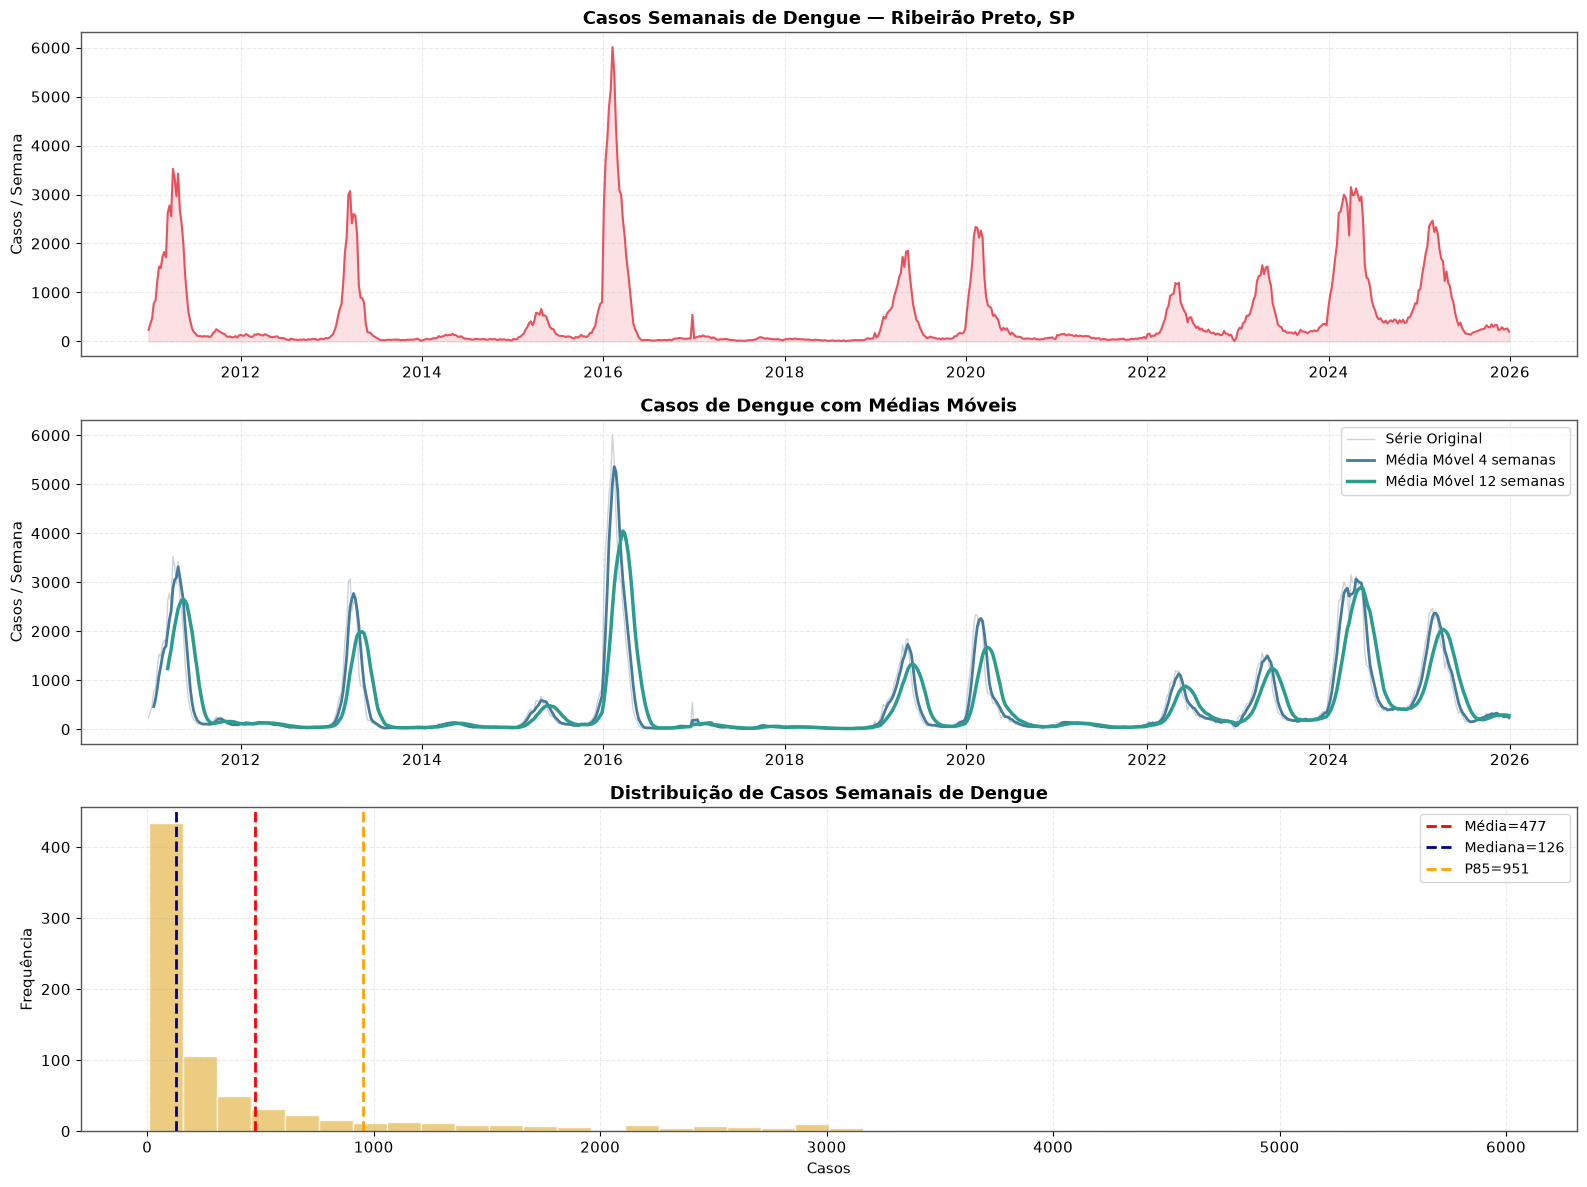

In [9]:
# Gráfico 1: Série temporal, médias móveis e distribuição dos casos
fig, eixos = plt.subplots(3, 1, figsize=(16, 12))

# --- Série bruta ---
eixos[0].plot(df.index, df[COLUNA_ALVO], color=PALETA[0], linewidth=1.5, alpha=0.85)
eixos[0].fill_between(df.index, 0, df[COLUNA_ALVO], color=PALETA[0], alpha=0.15)
eixos[0].set_title('Casos Semanais de Dengue — Ribeirão Preto, SP', fontweight='bold')
eixos[0].set_ylabel('Casos / Semana')
eixos[0].set_xlabel('')

# --- Médias móveis ---
media_movel_4  = df[COLUNA_ALVO].rolling(4).mean()
media_movel_12 = df[COLUNA_ALVO].rolling(12).mean()
eixos[1].plot(df.index, df[COLUNA_ALVO], color='#adb5bd', linewidth=1, label='Série Original', alpha=0.6)
eixos[1].plot(df.index, media_movel_4,  color=PALETA[1], linewidth=2,   label='Média Móvel 4 semanas')
eixos[1].plot(df.index, media_movel_12, color=PALETA[2], linewidth=2.5, label='Média Móvel 12 semanas')
eixos[1].set_title('Casos de Dengue com Médias Móveis', fontweight='bold')
eixos[1].set_ylabel('Casos / Semana')
eixos[1].legend()

# --- Distribuição ---
eixos[2].hist(df[COLUNA_ALVO], bins=40, color=PALETA[3], edgecolor='white', alpha=0.85)
eixos[2].axvline(df[COLUNA_ALVO].mean(),         color='red',    linestyle='--', linewidth=2,
                 label=f"Média={df[COLUNA_ALVO].mean():.0f}")
eixos[2].axvline(df[COLUNA_ALVO].median(),        color='navy',   linestyle='--', linewidth=2,
                 label=f"Mediana={df[COLUNA_ALVO].median():.0f}")
eixos[2].axvline(df[COLUNA_ALVO].quantile(0.85), color='orange', linestyle='--', linewidth=2,
                 label=f"P85={df[COLUNA_ALVO].quantile(0.85):.0f}")
eixos[2].set_title('Distribuição de Casos Semanais de Dengue', fontweight='bold')
eixos[2].set_xlabel('Casos')
eixos[2].set_ylabel('Frequência')
eixos[2].legend()

plt.tight_layout()
plt.savefig('eda_serie_dengue.png', dpi=150, bbox_inches='tight')
plt.show()

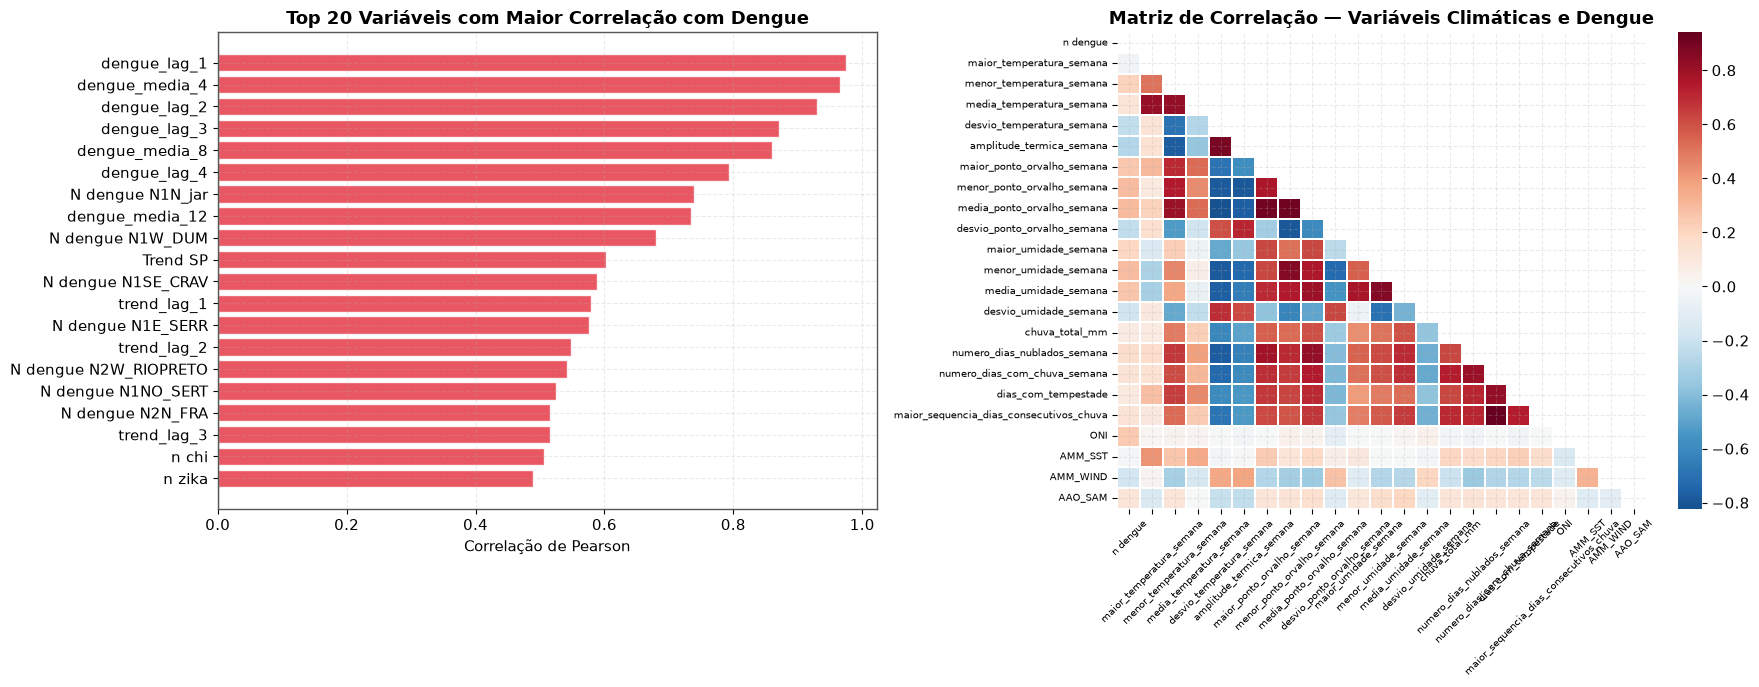

In [10]:
# Gráfico 2: Correlações e mapa de calor
df_numerico = df.select_dtypes(include=[np.number])
correlacoes = df_numerico.corrwith(df[COLUNA_ALVO]).drop(COLUNA_ALVO, errors='ignore')
correlacoes = correlacoes.dropna().sort_values(key=abs, ascending=False)

top20 = correlacoes.head(20)

fig, eixos = plt.subplots(1, 2, figsize=(18, 7))

cores_corr = [PALETA[0] if v > 0 else PALETA[1] for v in top20.values]
eixos[0].barh(top20.index, top20.values, color=cores_corr, edgecolor='white', alpha=0.85)
eixos[0].axvline(0, color='black', linewidth=0.8)
eixos[0].set_title('Top 20 Variáveis com Maior Correlação com Dengue', fontweight='bold')
eixos[0].set_xlabel('Correlação de Pearson')
eixos[0].invert_yaxis()

colunas_mapa_calor = [COLUNA_ALVO] + colunas_climaticas + indices_climaticos
colunas_mapa_calor = [c for c in colunas_mapa_calor if c in df_numerico.columns]
matriz_corr = df_numerico[colunas_mapa_calor].corr()
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mascara, ax=eixos[1], cmap='RdBu_r',
            center=0, annot=False, linewidths=0.3,
            xticklabels=matriz_corr.columns, yticklabels=matriz_corr.columns)
eixos[1].set_title('Matriz de Correlação — Variáveis Climáticas e Dengue', fontweight='bold')
eixos[1].tick_params(axis='x', rotation=45, labelsize=7)
eixos[1].tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('eda_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

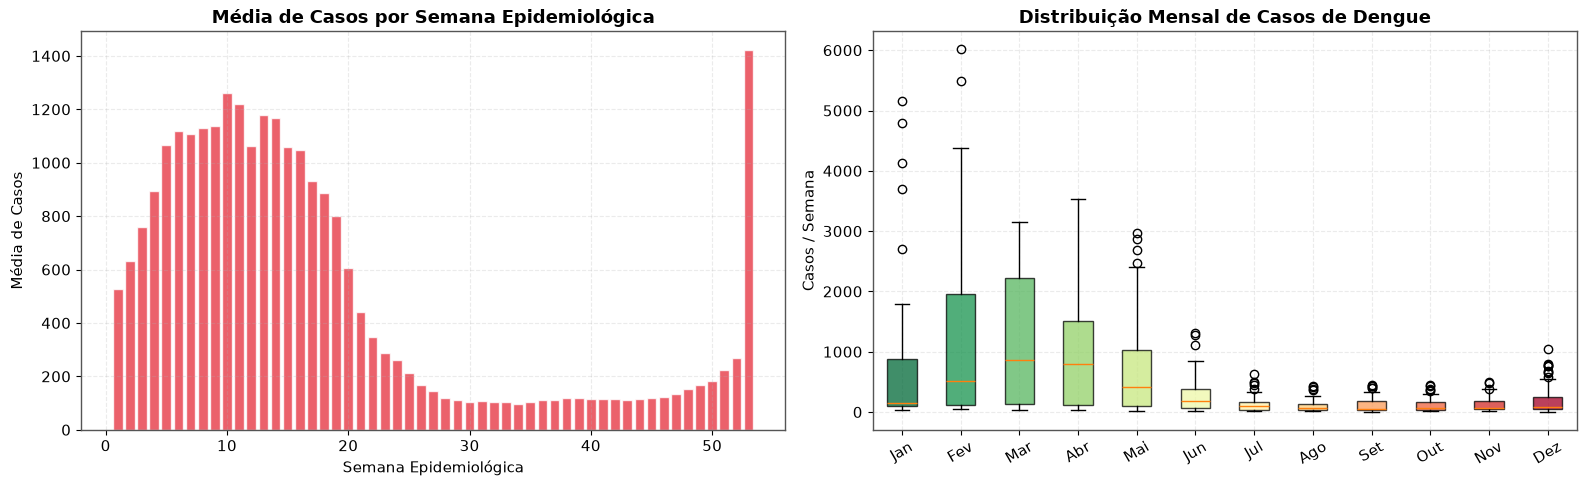

In [11]:
# Gráfico 3: Sazonalidade epidemiológica e distribuição mensal
df['semana_do_ano'] = df.index.isocalendar().week.astype(int)
media_por_semana = df.groupby('semana_do_ano')[COLUNA_ALVO].mean()

fig, eixos = plt.subplots(1, 2, figsize=(16, 5))

eixos[0].bar(media_por_semana.index, media_por_semana.values,
             color=PALETA[0], alpha=0.8, edgecolor='white')
eixos[0].set_title('Média de Casos por Semana Epidemiológica', fontweight='bold')
eixos[0].set_xlabel('Semana Epidemiológica')
eixos[0].set_ylabel('Média de Casos')

df['mes'] = df.index.month
nomes_meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
dados_mensais = [df[df['mes'] == m][COLUNA_ALVO].values for m in range(1, 13)]
bp = eixos[1].boxplot(dados_mensais, patch_artist=True, notch=False)
for patch, cor in zip(bp['boxes'], plt.cm.RdYlGn_r(np.linspace(0, 1, 12))):
    patch.set_facecolor(cor)
    patch.set_alpha(0.75)
eixos[1].set_xticklabels(nomes_meses, rotation=30)
eixos[1].set_title('Distribuição Mensal de Casos de Dengue', fontweight='bold')
eixos[1].set_ylabel('Casos / Semana')

plt.tight_layout()
plt.savefig('eda_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Definição do Rótulo e Engenharia de Features

### 4.1 Definição do Rótulo de Surto

Utilizamos o **Canal Endêmico** como critério para classificar uma semana como 'surto':
- Para cada semana epidemiológica, calculamos o **75º percentil histórico** (P75)
- Uma semana é marcada como surto se os casos ultrapassarem esse limiar **por pelo menos 3 semanas consecutivas**
- O rótulo é deslocado **16 semanas no futuro** — o modelo aprende a prever com antecedência

### 4.2 Engenharia de Features

Criamos variáveis derivadas para capturar:
- **Defasagens (lags)** dos casos e variáveis climáticas
- **Estatísticas móveis** (média, desvio padrão, máximo, mínimo)
- **Sazonalidade cíclica** (seno e cosseno da semana do ano)
- **Taxa de variação e aceleração** dos casos
- **Distribuição espacial** entre sub-regiões
- **Índices climáticos** com defasagem (ONI, AMM, AAO)

In [12]:
HORIZONTE_PREDICAO = 16

In [13]:
# Definição do rótulo de surto
if df['ano'].nunique() >= 3:
    limiar_semana = (
        df.groupby('semana_epidemiologica')[COLUNA_ALVO]
          .quantile(0.75)
          .rename('limiar_p75')
    )
    df = df.join(limiar_semana, on='semana_epidemiologica')
    df['limite_surto'] = df['limiar_p75']
    metodo_usado = 'P75 por semana epidemiológica (Canal Endêmico)'
else:
    p85_global = df[COLUNA_ALVO].quantile(0.85)
    df['limite_surto'] = p85_global
    metodo_usado = 'P85 global (fallback para poucos anos)'

df['acima_limite'] = (df[COLUNA_ALVO] > df['limite_surto']).astype(int)

casos_roll3 = df[COLUNA_ALVO].rolling(3, min_periods=1).mean()
df['surto_persistente'] = (
    (df['acima_limite'] == 1) &
    (casos_roll3 > df['limite_surto'] * 1.1)
).astype(int)

df['rotulo_surto'] = df['surto_persistente'].shift(-HORIZONTE_PREDICAO)

df_valido = df.dropna(subset=['rotulo_surto'])
contagens = df_valido['rotulo_surto'].value_counts()
total = len(df_valido)
print(f'Método de limiarização: {metodo_usado}')
print(f'Horizonte de previsão : {HORIZONTE_PREDICAO} semanas à frente\n')
for classe, cnt in contagens.items():
    nome_classe = 'Surto  ' if classe == 1 else 'Normal '
    print(f'   Classe {int(classe)} ({nome_classe}): {cnt:>4} semanas ({cnt/total*100:.1f}%)')

Método de limiarização: P75 por semana epidemiológica (Canal Endêmico)
Horizonte de previsão : 16 semanas à frente

   Classe 0 (Normal ):  593 semanas (77.2%)
   Classe 1 (Surto  ):  175 semanas (22.8%)


In [14]:
# Engenharia de features
fe = df.copy()

print('A) Criando features de defasagem dos casos de dengue...')
for defasagem in [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 16]:
    fe[f'dengue_lag_{defasagem}'] = fe[COLUNA_ALVO].shift(defasagem)

print('B) Criando estatísticas de janelas móveis...')
for janela in [4, 8, 12]:
    fe[f'dengue_media_movel_{janela}']  = fe[COLUNA_ALVO].rolling(janela).mean()
    fe[f'dengue_desvio_movel_{janela}'] = fe[COLUNA_ALVO].rolling(janela).std()
    fe[f'dengue_maximo_movel_{janela}'] = fe[COLUNA_ALVO].rolling(janela).max()
    fe[f'dengue_minimo_movel_{janela}'] = fe[COLUNA_ALVO].rolling(janela).min()

print('C) Criando features climáticas com defasagem...')
variaveis_climaticas_base = [
    'media_temperatura_semana', 'media_umidade_semana',
    'chuva_total_mm', 'media_ponto_orvalho_semana', 'amplitude_termica_semana'
]
variaveis_climaticas_base = [c for c in variaveis_climaticas_base if c in fe.columns]
for col in variaveis_climaticas_base:
    for lag in [1, 2, 4, 8]:
        fe[f'{col}_lag{lag}'] = fe[col].shift(lag)
    fe[f'{col}_media_movel4'] = fe[col].rolling(4).mean()
    fe[f'{col}_media_movel8'] = fe[col].rolling(8).mean()

print('D) Adicionando índices de teleconexão climática com defasagem...')
for indice in indices_climaticos:
    if indice in fe.columns:
        for lag in [4, 8, 12]:
            fe[f'{indice}_lag{lag}'] = fe[indice].shift(lag)

print('E) Calculando features de distribuição espacial...')
colunas_espaciais_disp = [c for c in colunas_espaciais if c in fe.columns]
if colunas_espaciais_disp:
    fe['total_sub_regioes'] = fe[colunas_espaciais_disp].sum(axis=1).replace(0, np.nan)
    for col in colunas_espaciais_disp:
        fe[f'{col}_proporcao'] = fe[col] / fe['total_sub_regioes']
    fe['entropia_espacial'] = -(
        fe[[f'{c}_proporcao' for c in colunas_espaciais_disp]]
        .clip(lower=1e-9)
        .apply(lambda x: x * np.log(x), axis=1)
        .sum(axis=1)
    )
    fe['concentracao_espacial'] = (
        fe[colunas_espaciais_disp].max(axis=1) / fe['total_sub_regioes'].replace(0, np.nan)
    )

print('F) Criando features sazonais cíclicas...')
fe['semana_seno'] = np.sin(2 * np.pi * fe['semana_do_ano'] / 52)
fe['semana_cosseno'] = np.cos(2 * np.pi * fe['semana_do_ano'] / 52)

print('G) Criando features de variação e aceleração dos casos...')
fe['variacao_percentual_1s'] = fe[COLUNA_ALVO].pct_change(1)
fe['variacao_percentual_4s'] = fe[COLUNA_ALVO].pct_change(4)
fe['velocidade_casos']       = fe[COLUNA_ALVO].diff(1)
fe['aceleracao_casos']       = fe['velocidade_casos'].diff(1)

if 'predominancia_direcao_vento_semana' in fe.columns:
    fe = pd.get_dummies(fe, columns=['predominancia_direcao_vento_semana'],
                        prefix='vento', drop_first=False)

fe['dengue_lag_52s'] = fe[COLUNA_ALVO].shift(52)
print('\n✓ Engenharia de features concluída!')

A) Criando features de defasagem dos casos de dengue...
B) Criando estatísticas de janelas móveis...
C) Criando features climáticas com defasagem...
D) Adicionando índices de teleconexão climática com defasagem...
E) Calculando features de distribuição espacial...
F) Criando features sazonais cíclicas...
G) Criando features de variação e aceleração dos casos...

✓ Engenharia de features concluída!


---
## 5. Modelagem com Random Forest

O **Random Forest** é um ensemble de árvores de decisão que:
- Combina centenas de árvores treinadas em subconjuntos aleatórios dos dados
- É robusto a overfitting e ruído nas features
- Lida naturalmente com dados desbalanceados via `class_weight='balanced'`

### Processo:
1. **Baseline**: treinamos um modelo inicial com hiperparâmetros padrão
2. **Otimização**: usamos GridSearchCV com validação cruzada temporal (TimeSeriesSplit)
   - Isso evita vazamento de dados futuros para o passado
   - Otimizamos pelo ROC-AUC, que é mais adequado para classes desbalanceadas
3. **Avaliação**: matriz de confusão, curva ROC, importância das variáveis
4. **Importância por permutação**: avalia o impacto real de cada variável no desempenho

In [15]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.inspection import permutation_importance

# Preparação dos dados
COLUNA_ROTULO = 'rotulo_surto'

fe_limpo = fe.dropna(subset=[COLUNA_ROTULO]).copy()

COLUNAS_EXCLUIDAS = [
    COLUNA_ALVO, 'n zika', 'n chi', COLUNA_ROTULO,
    'limite_surto', 'acima_limite', 'surto_persistente',
    'ano', 'Ano_Seman', 'linha_original', 'semana_do_ano', 'mes',
    'dengue_ano_passado', 'surto_ano_anterior_norm', 'surto_ano_anterior',
    'limiar_p75', 'Trend SP',
]

colunas_features = [
    c for c in fe_limpo.select_dtypes(include=[np.number]).columns
    if c not in COLUNAS_EXCLUIDAS and not c.startswith('N dengue N')
]

fe_limpo[colunas_features] = fe_limpo[colunas_features].ffill().bfill().fillna(0)

X = fe_limpo[colunas_features]
y = fe_limpo[COLUNA_ROTULO].astype(int)

indice_divisao = int(len(X) * 0.80)
X_treino, X_teste = X.iloc[:indice_divisao], X.iloc[indice_divisao:]
y_treino, y_teste = y.iloc[:indice_divisao], y.iloc[indice_divisao:]

normalizador = StandardScaler()
X_treino_norm = pd.DataFrame(
    normalizador.fit_transform(X_treino), columns=colunas_features, index=X_treino.index
)
X_teste_norm = pd.DataFrame(
    normalizador.transform(X_teste), columns=colunas_features, index=X_teste.index
)

print(f'Amostras de treino : {len(X_treino)}')
print(f'Amostras de teste  : {len(X_teste)}')
print(f'Features utilizadas: {len(colunas_features)}')

Amostras de treino : 614
Amostras de teste  : 154
Features utilizadas: 117


In [16]:
# Modelo Baseline
rf_baseline = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_split=10,
    min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_baseline.fit(X_treino, y_treino)
y_pred_baseline = rf_baseline.predict(X_teste)
y_prob_baseline = rf_baseline.predict_proba(X_teste)[:, 1]
print('✓ Modelo baseline treinado.')

✓ Modelo baseline treinado.


In [ ]:
# Otimização com GridSearchCV + validação cruzada temporal
print('Iniciando busca em grade (isso pode demorar alguns minutos)...')
tscv = TimeSeriesSplit(n_splits=5)

grade_parametros = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    grade_parametros, cv=tscv, scoring='roc_auc', n_jobs=-1, verbose=1, refit=True
)
rf_grid.fit(X_treino, y_treino)

rf_otimizado = rf_grid.best_estimator_
y_pred_rf = rf_otimizado.predict(X_teste)
y_prob_rf  = rf_otimizado.predict_proba(X_teste)[:, 1]

print(f'\nMelhores hiperparâmetros: {rf_grid.best_params_}')
print(f'Melhor ROC-AUC (CV)     : {rf_grid.best_score_:.4f}')

Iniciando busca em grade (isso pode demorar alguns minutos)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Melhores hiperparâmetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 100}
Melhor ROC-AUC (CV)     : nan


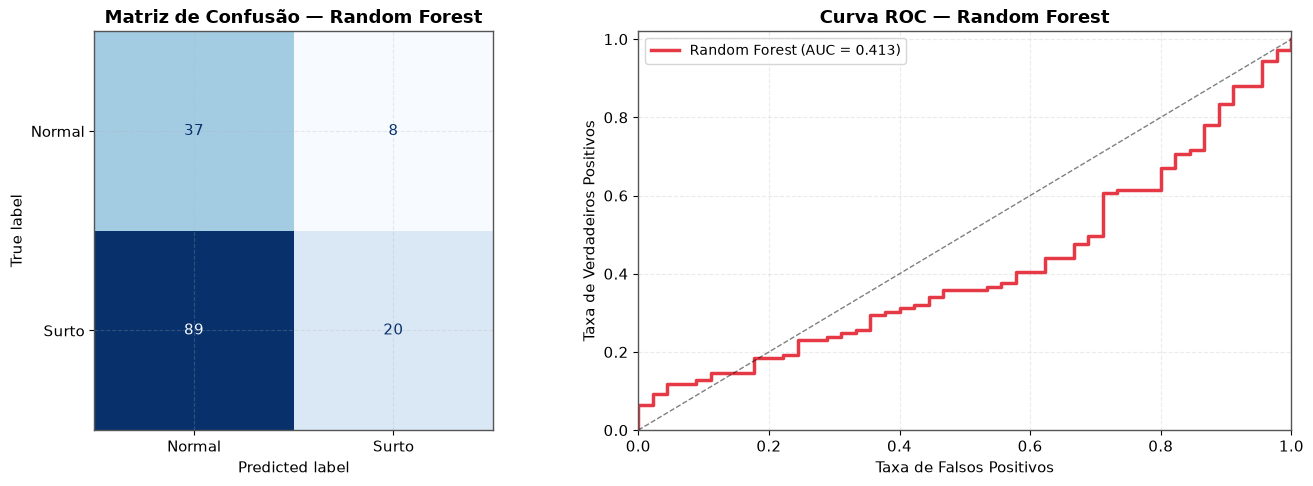


Random Forest Otimizado — Resumo:
  Acurácia    : 0.3701
  Precisão    : 0.7143
  Recall      : 0.1835
  F1-Score    : 0.2920
  ROC-AUC     : 0.4135


In [18]:
# Função de avaliação unificada
def avaliar_classificador(y_verdadeiro, y_previsto, y_probabilidade, nome_modelo='Modelo'):
    acuracia  = accuracy_score(y_verdadeiro, y_previsto)
    precisao  = precision_score(y_verdadeiro, y_previsto, zero_division=0)
    recall    = recall_score(y_verdadeiro, y_previsto, zero_division=0)
    f1        = f1_score(y_verdadeiro, y_previsto, zero_division=0)
    try:
        roc = roc_auc_score(y_verdadeiro, y_probabilidade)
    except:
        roc = float('nan')
    return {
        'modelo': nome_modelo,
        'Acurácia': acuracia,
        'Precisão': precisao,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc,
    }

metricas_rf = avaliar_classificador(y_teste, y_pred_rf, y_prob_rf, 'Random Forest (Otimizado)')

# Visualização: Matriz de Confusão + Curva ROC
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

mc = confusion_matrix(y_teste, y_pred_rf)
ConfusionMatrixDisplay(mc, display_labels=['Normal', 'Surto']).plot(
    ax=eixos[0], colorbar=False, cmap='Blues'
)
eixos[0].set_title('Matriz de Confusão — Random Forest', fontweight='bold')

if not np.isnan(metricas_rf['ROC-AUC']):
    fpr, tpr, _ = roc_curve(y_teste, y_prob_rf)
    eixos[1].plot(fpr, tpr, color=PALETA[0], linewidth=2.5,
                  label=f"Random Forest (AUC = {metricas_rf['ROC-AUC']:.3f})")
eixos[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
eixos[1].set_xlim([0, 1]); eixos[1].set_ylim([0, 1.02])
eixos[1].set_title('Curva ROC — Random Forest', fontweight='bold')
eixos[1].set_xlabel('Taxa de Falsos Positivos')
eixos[1].set_ylabel('Taxa de Verdadeiros Positivos')
eixos[1].legend()

plt.tight_layout()
plt.savefig('avaliacao_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRandom Forest Otimizado — Resumo:")
for k, v in metricas_rf.items():
    if k != 'modelo':
        print(f'  {k:<12}: {v:.4f}')

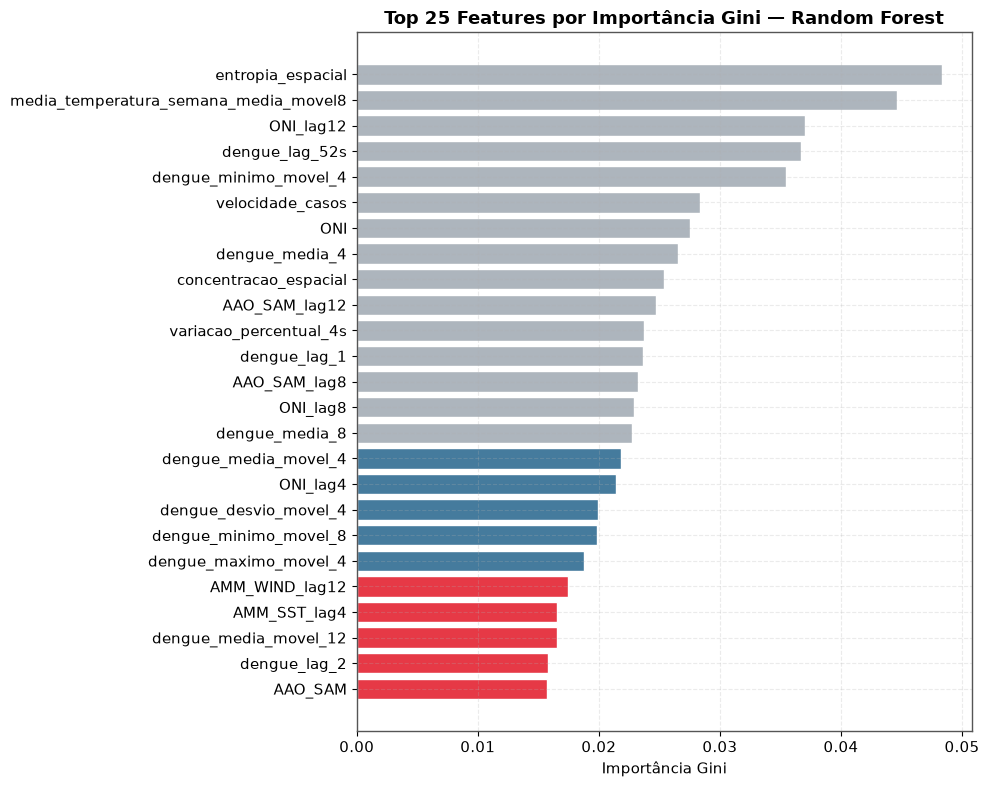

In [19]:
# Importância das features (Gini + Permutação)
importancias = pd.Series(rf_otimizado.feature_importances_, index=colunas_features)
importancias = importancias.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
cores_imp = [PALETA[0] if i < 5 else PALETA[1] if i < 10 else '#adb5bd' for i in range(len(importancias))]
ax.barh(importancias.index, importancias.values, color=cores_imp[::-1], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 25 Features por Importância Gini — Random Forest', fontweight='bold')
ax.set_xlabel('Importância Gini')
plt.tight_layout()
plt.savefig('importancia_gini_rf.png', dpi=150, bbox_inches='tight')
plt.show()

Calculando importância por permutação (pode demorar um pouco)...


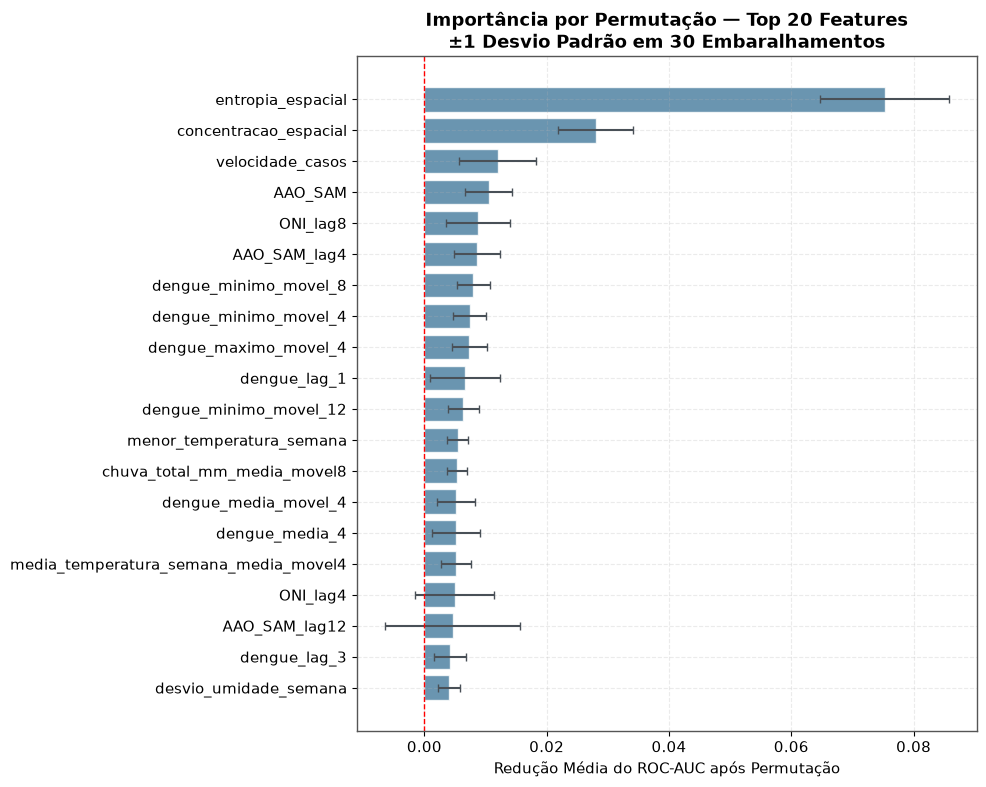

In [20]:
# Importância por Permutação
print('Calculando importância por permutação (pode demorar um pouco)...')
perm_imp = permutation_importance(
    rf_otimizado, X_teste, y_teste,
    n_repeats=30, random_state=42, n_jobs=-1, scoring='roc_auc'
)

df_permutacao = pd.DataFrame({
    'feature'     : colunas_features,
    'importancia' : perm_imp.importances_mean,
    'desvio'      : perm_imp.importances_std
}).sort_values('importancia', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_permutacao['feature'], df_permutacao['importancia'],
        xerr=df_permutacao['desvio'], color=PALETA[1], alpha=0.8,
        edgecolor='white', ecolor='#495057', capsize=3)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title(
    'Importância por Permutação — Top 20 Features\n±1 Desvio Padrão em 30 Embaralhamentos',
    fontweight='bold'
)
ax.set_xlabel('Redução Média do ROC-AUC após Permutação')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('importancia_permutacao.png', dpi=150, bbox_inches='tight')
plt.show()

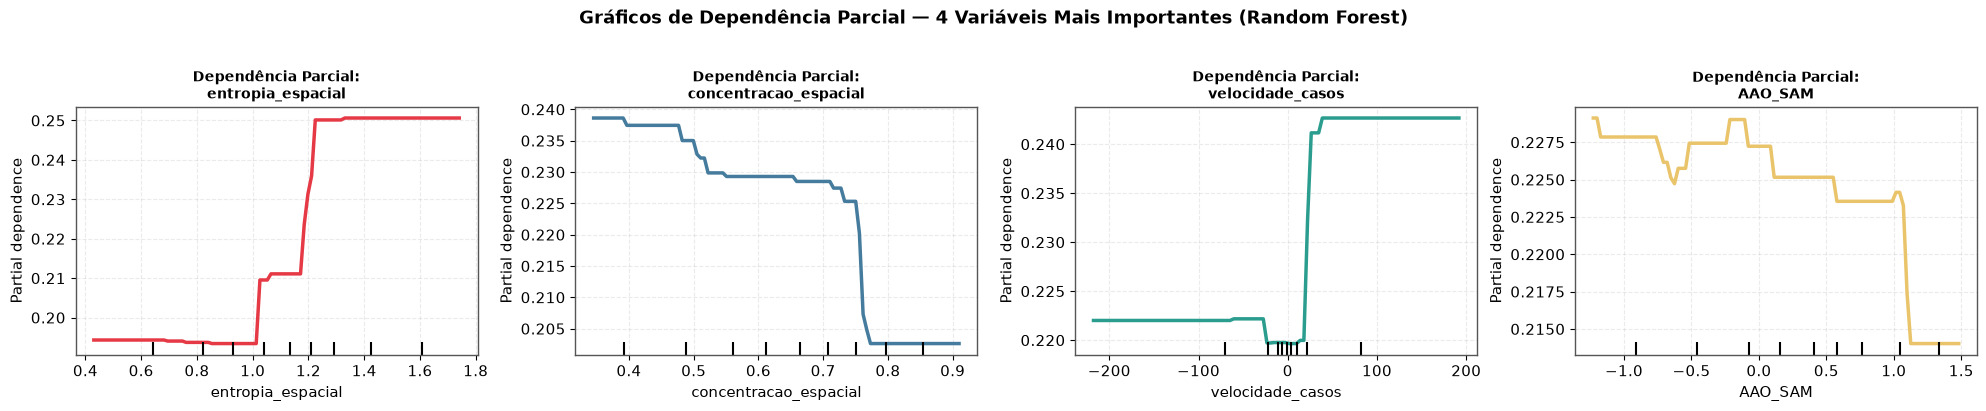

In [21]:
# Gráficos de Dependência Parcial (PDP)
from sklearn.inspection import PartialDependenceDisplay

top4_features = df_permutacao['feature'].head(4).tolist()
top4_features = [f for f in top4_features if f in colunas_features][:4]

if top4_features:
    fig, eixos = plt.subplots(1, len(top4_features), figsize=(5 * len(top4_features), 4))
    if len(top4_features) == 1:
        eixos = [eixos]
    for i, feat in enumerate(top4_features):
        idx_feat = colunas_features.index(feat)
        PartialDependenceDisplay.from_estimator(
            rf_otimizado, X_treino, [idx_feat], ax=eixos[i],
            kind='average',
            line_kw={'color': PALETA[i % len(PALETA)], 'linewidth': 2.5}
        )
        eixos[i].set_title(f'Dependência Parcial:\n{feat}', fontweight='bold', fontsize=10)
        eixos[i].set_xlabel(feat, fontsize=8)
        eixos[i].set_ylabel('Prob. Prevista de Surto', fontsize=8)
    plt.suptitle(
        'Gráficos de Dependência Parcial — 4 Variáveis Mais Importantes (Random Forest)',
        fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig('dependencia_parcial.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. LSTM Implementado do Zero com NumPy

Esta seção implementa manualmente uma célula LSTM usando apenas NumPy, sem frameworks de deep learning.

### Por que fazer isso?
- Transparência total sobre o funcionamento interno do LSTM
- Controle explícito de cada porta (forget, input, gate, output)
- Útil para fins didáticos e auditoria do modelo

### Arquitetura:
O **LSTM (Long Short-Term Memory)** resolve o problema de gradientes que desaparecem em RNNs comuns:
- **Porta de esquecimento (f)**: decide o que descartar do estado de célula anterior
- **Porta de entrada (i)**: decide quais novas informações armazenar
- **Gate de célula (g)**: candidatos a novas informações
- **Porta de saída (o)**: decide quais partes do estado de célula serão a saída

### Limitação:
Como o treinamento é via gradiente numérico, apenas os pesos da camada de saída (`Wy`, `by`) são atualizados eficientemente. Os pesos das portas são inicializados com boas heurísticas mas não são otimizados por backpropagation completo — isso é feito corretamente na versão PyTorch.

In [22]:
class CelulaLSTM:
    """LSTM implementado do zero com NumPy para fins didáticos."""

    def __init__(self, tamanho_entrada, tamanho_oculto, semente=42):
        rng = np.random.default_rng(semente)
        escala_e = np.sqrt(2.0 / (tamanho_entrada + tamanho_oculto))
        escala_h = np.sqrt(2.0 / (tamanho_oculto + tamanho_oculto))

        # Pesos da porta de esquecimento
        self.Wf = rng.normal(0, escala_e, (tamanho_oculto, tamanho_entrada))
        self.Uf = rng.normal(0, escala_h, (tamanho_oculto, tamanho_oculto))
        self.bf = np.zeros((tamanho_oculto, 1))

        # Pesos da porta de entrada
        self.Wi = rng.normal(0, escala_e, (tamanho_oculto, tamanho_entrada))
        self.Ui = rng.normal(0, escala_h, (tamanho_oculto, tamanho_oculto))
        self.bi = np.zeros((tamanho_oculto, 1))

        # Pesos do gate de célula
        self.Wg = rng.normal(0, escala_e, (tamanho_oculto, tamanho_entrada))
        self.Ug = rng.normal(0, escala_h, (tamanho_oculto, tamanho_oculto))
        self.bg = np.zeros((tamanho_oculto, 1))

        # Pesos da porta de saída
        self.Wo = rng.normal(0, escala_e, (tamanho_oculto, tamanho_entrada))
        self.Uo = rng.normal(0, escala_h, (tamanho_oculto, tamanho_oculto))
        self.bo = np.zeros((tamanho_oculto, 1))

        # Camada de saída
        self.Wy = rng.normal(0, np.sqrt(2.0 / tamanho_oculto), (1, tamanho_oculto))
        self.by = np.zeros((1, 1))

        self.tamanho_oculto = tamanho_oculto
        self.tamanho_entrada = tamanho_entrada

    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    @staticmethod
    def tanh(x):
        return np.tanh(np.clip(x, -500, 500))

    def propagar_sequencia(self, sequencia_X):
        """Propagação forward por uma sequência temporal."""
        h = np.zeros((self.tamanho_oculto, 1))  # estado oculto
        c = np.zeros((self.tamanho_oculto, 1))  # estado de célula

        for t in range(len(sequencia_X)):
            x = sequencia_X[t].reshape(-1, 1)

            # Cálculo de cada porta
            f = self.sigmoid(self.Wf @ x + self.Uf @ h + self.bf)  # porta de esquecimento
            i = self.sigmoid(self.Wi @ x + self.Ui @ h + self.bi)  # porta de entrada
            g = self.tanh(self.Wg @ x + self.Ug @ h + self.bg)    # gate de célula
            o = self.sigmoid(self.Wo @ x + self.Uo @ h + self.bo)  # porta de saída

            # Atualização do estado de célula e estado oculto
            c = f * c + i * g
            h = o * self.tanh(c)

        # Saída: probabilidade de surto
        y = self.sigmoid(self.Wy @ h + self.by)
        return y.item(), h, c

    def prever_lote(self, sequencias_X):
        previsoes = []
        for seq in sequencias_X:
            prob, _, _ = self.propagar_sequencia(seq)
            previsoes.append(prob)
        return np.array(previsoes)

print('✓ Classe CelulaLSTM (NumPy) definida.')

✓ Classe CelulaLSTM (NumPy) definida.


In [23]:
# Preparação das sequências para o LSTM
from sklearn.preprocessing import MinMaxScaler

candidatos_lstm = df_permutacao['feature'].head(10).tolist()
variaveis_clima_essenciais = [
    'media_temperatura_semana', 'chuva_total_mm',
    'media_umidade_semana', 'ONI', 'semana_sin', 'semana_cos'
]

features_lstm = list(dict.fromkeys(
    candidatos_lstm + [f for f in variaveis_clima_essenciais if f in colunas_features]
))
features_lstm = [f for f in features_lstm if f in colunas_features][:15]

normalizador_lstm = MinMaxScaler()
X_lstm_completo = fe_limpo[features_lstm].ffill().bfill().fillna(0)
X_lstm_norm = normalizador_lstm.fit_transform(X_lstm_completo)
y_lstm_completo = fe_limpo[COLUNA_ROTULO].astype(int).values

COMPRIMENTO_SEQUENCIA = 12  # 12 semanas de contexto temporal

def construir_sequencias(X_arr, y_arr, comp_seq):
    """Transforma a série temporal em sequências de comprimento fixo."""
    Xs, ys = [], []
    for i in range(comp_seq, len(X_arr)):
        Xs.append(X_arr[i - comp_seq:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = construir_sequencias(X_lstm_norm, y_lstm_completo, COMPRIMENTO_SEQUENCIA)

divisao_seq = int(len(X_seq) * 0.80)
X_seq_treino = X_seq[:divisao_seq]
X_seq_teste  = X_seq[divisao_seq:]
y_seq_treino = y_seq[:divisao_seq]
y_seq_teste  = y_seq[divisao_seq:]

print(f'Sequências de treino : {X_seq_treino.shape}')
print(f'Sequências de teste  : {X_seq_teste.shape}')
print(f'Features no LSTM     : {len(features_lstm)}')

Sequências de treino : (604, 12, 15)
Sequências de teste  : (152, 12, 15)
Features no LSTM     : 15


In [24]:
# Treinamento do LSTM NumPy
def entropia_cruzada_binaria(y_verdadeiro, y_previsto, eps=1e-9):
    y_previsto = np.clip(y_previsto, eps, 1 - eps)
    return -np.mean(y_verdadeiro * np.log(y_previsto) + (1 - y_verdadeiro) * np.log(1 - y_previsto))

N_FEATURES_LSTM = len(features_lstm)
TAMANHO_OCULTO  = 32
EPOCAS          = 50
TAMANHO_LOTE    = 16
TAXA_APRENDIZADO = 0.01

lstm_numpy = CelulaLSTM(tamanho_entrada=N_FEATURES_LSTM, tamanho_oculto=TAMANHO_OCULTO)

# Pesos amostrais para lidar com desbalanceamento
n_surto  = y_seq_treino.sum()
n_normal = len(y_seq_treino) - n_surto
peso_positivo = n_normal / max(n_surto, 1)
pesos_amostras = np.where(y_seq_treino == 1, peso_positivo, 1.0)
pesos_amostras /= pesos_amostras.sum()

perdas_treino = []
perdas_validacao = []

rng = np.random.default_rng(42)

for epoca in range(EPOCAS):
    indices = rng.choice(len(X_seq_treino), size=len(X_seq_treino), replace=False, p=pesos_amostras)
    perda_epoca = 0.0

    for inicio in range(0, len(indices), TAMANHO_LOTE):
        idx_lote = indices[inicio:inicio + TAMANHO_LOTE]
        grad_Wy = np.zeros_like(lstm_numpy.Wy)
        grad_by = np.zeros_like(lstm_numpy.by)
        perda_lote = 0.0

        for bi in idx_lote:
            seq = X_seq_treino[bi]
            verdadeiro = float(y_seq_treino[bi])
            previsto, h, c = lstm_numpy.propagar_sequencia(seq)
            previsto = np.clip(previsto, 1e-9, 1 - 1e-9)
            perda = -(verdadeiro * np.log(previsto) + (1 - verdadeiro) * np.log(1 - previsto))
            perda_lote += perda
            dL_dy = -(verdadeiro / previsto - (1 - verdadeiro) / (1 - previsto))
            dlogit = dL_dy * previsto * (1 - previsto)
            grad_Wy += dlogit * h.T
            grad_by += dlogit

        n_lote = max(len(idx_lote), 1)
        lstm_numpy.Wy -= TAXA_APRENDIZADO * grad_Wy / n_lote
        lstm_numpy.by -= TAXA_APRENDIZADO * grad_by / n_lote
        perda_epoca += perda_lote / n_lote

    previsoes_val = lstm_numpy.prever_lote(X_seq_teste)
    perda_val = entropia_cruzada_binaria(y_seq_teste, previsoes_val)
    perdas_treino.append(float(perda_epoca) / max(len(X_seq_treino) // TAMANHO_LOTE, 1))
    perdas_validacao.append(float(perda_val))

    if (epoca + 1) % 10 == 0:
        print(f'Época {epoca+1:>3}/{EPOCAS} | Perda Treino: {perdas_treino[-1]:.4f} | Perda Val: {perdas_validacao[-1]:.4f}')

print('\n✓ Treinamento do LSTM NumPy concluído!')

Época  10/50 | Perda Treino: 0.3830 | Perda Val: 1.1723
Época  20/50 | Perda Treino: 0.3397 | Perda Val: 1.4142
Época  30/50 | Perda Treino: 0.3293 | Perda Val: 1.5416
Época  40/50 | Perda Treino: 0.3259 | Perda Val: 1.6127
Época  50/50 | Perda Treino: 0.3244 | Perda Val: 1.6533

✓ Treinamento do LSTM NumPy concluído!


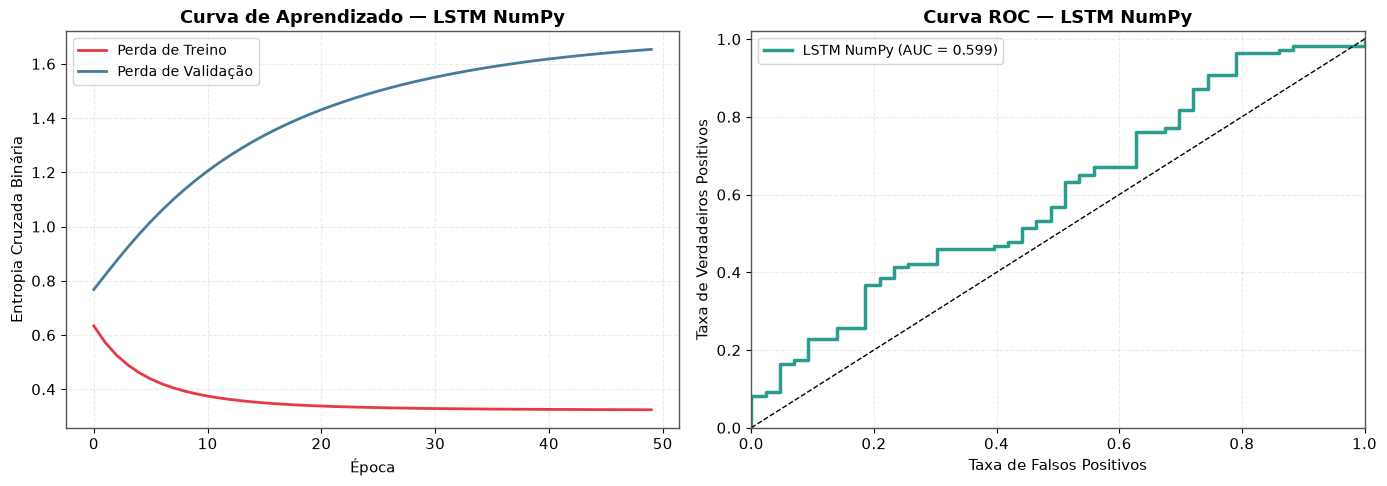


LSTM NumPy — Resumo:
  Acurácia    : 0.4934
  Precisão    : 0.8333
  Recall      : 0.3670
  F1-Score    : 0.5096
  ROC-AUC     : 0.5989


In [25]:
# Avaliação do LSTM NumPy
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].plot(perdas_treino,    color=PALETA[0], linewidth=2, label='Perda de Treino')
eixos[0].plot(perdas_validacao, color=PALETA[1], linewidth=2, label='Perda de Validação')
eixos[0].set_title('Curva de Aprendizado — LSTM NumPy', fontweight='bold')
eixos[0].set_xlabel('Época')
eixos[0].set_ylabel('Entropia Cruzada Binária')
eixos[0].legend()

y_prob_lstm_numpy = lstm_numpy.prever_lote(X_seq_teste)

if len(np.unique(y_seq_teste)) > 1:
    fpr_l, tpr_l, limiares_l = roc_curve(y_seq_teste, y_prob_lstm_numpy)
    J = tpr_l - fpr_l
    limiar_otimo = limiares_l[np.argmax(J)]
    roc_lstm_numpy = roc_auc_score(y_seq_teste, y_prob_lstm_numpy)
    eixos[1].plot(fpr_l, tpr_l, color=PALETA[2], linewidth=2.5,
                  label=f'LSTM NumPy (AUC = {roc_lstm_numpy:.3f})')
    eixos[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
else:
    limiar_otimo = 0.5
    roc_lstm_numpy = float('nan')

eixos[1].set_xlim([0, 1]); eixos[1].set_ylim([0, 1.02])
eixos[1].set_title('Curva ROC — LSTM NumPy', fontweight='bold')
eixos[1].set_xlabel('Taxa de Falsos Positivos')
eixos[1].set_ylabel('Taxa de Verdadeiros Positivos')
eixos[1].legend()

plt.tight_layout()
plt.savefig('avaliacao_lstm_numpy.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_lstm_numpy = (y_prob_lstm_numpy >= limiar_otimo).astype(int)
metricas_lstm_numpy = avaliar_classificador(y_seq_teste, y_pred_lstm_numpy, y_prob_lstm_numpy, 'LSTM (NumPy)')
metricas_lstm_numpy['ROC-AUC'] = roc_lstm_numpy

print(f"\nLSTM NumPy — Resumo:")
for k, v in metricas_lstm_numpy.items():
    if k != 'modelo':
        print(f'  {k:<12}: {v:.4f}')

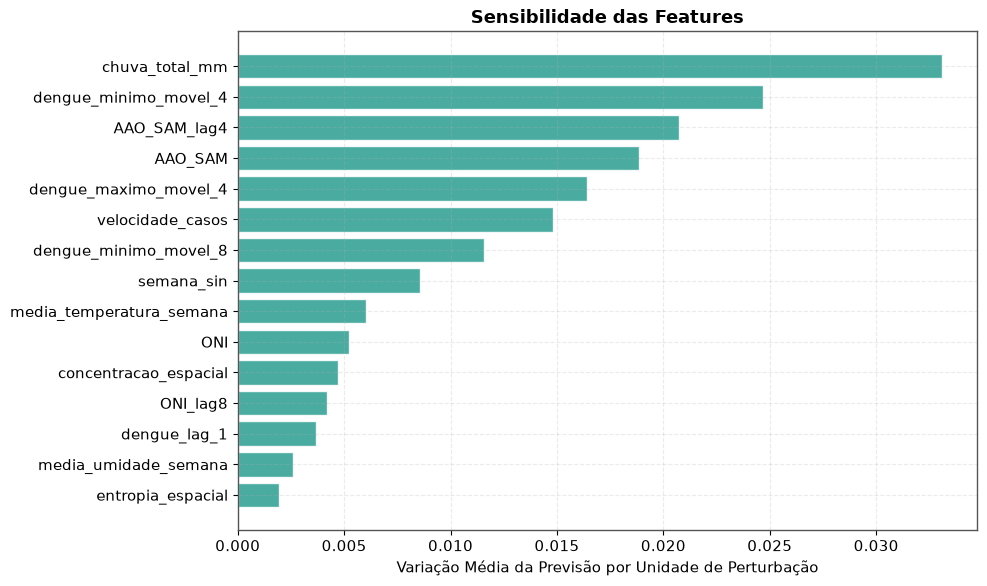

In [26]:
# Análise de sensibilidade das features no LSTM NumPy
def sensibilidade_features_lstm(modelo, sequencias_X, perturbacao=0.1):
    """Mede o impacto de cada feature nas previsões do LSTM via perturbação."""
    n_amostras, comp_seq, n_feat = sequencias_X.shape
    sensibilidades = np.zeros(n_feat)
    previsoes_base = modelo.prever_lote(sequencias_X)

    for idx_feat in range(n_feat):
        X_perturbado = sequencias_X.copy()
        X_perturbado[:, :, idx_feat] += perturbacao
        previsoes_perturbadas = modelo.prever_lote(X_perturbado)
        sensibilidades[idx_feat] = np.mean(np.abs(previsoes_perturbadas - previsoes_base)) / perturbacao

    return sensibilidades

sensibilidades = sensibilidade_features_lstm(lstm_numpy, X_seq_teste, perturbacao=0.1)
df_sensibilidade = pd.DataFrame({
    'feature': features_lstm,
    'sensibilidade': sensibilidades
}).sort_values('sensibilidade', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_sensibilidade['feature'], df_sensibilidade['sensibilidade'],
        color=PALETA[2], alpha=0.85, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Sensibilidade das Features', fontweight='bold')
ax.set_xlabel('Variação Média da Previsão por Unidade de Perturbação')
plt.tight_layout()
plt.savefig('sensibilidade_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. LSTM Implementado com PyTorch

Esta seção implementa o mesmo problema usando o módulo `nn.LSTM` do **PyTorch**, com treinamento por backpropagation completo (BPTT — Backpropagation Through Time).

### Diferenças em relação ao LSTM NumPy:
| Aspecto | LSTM NumPy | LSTM PyTorch |
|---------|------------|-------------|
| Backpropagation | Apenas camada de saída | Completo (todas as portas) |
| Otimizador | SGD manual | Adam (adaptativo) |
| Velocidade | Lento (puro Python) | Rápido (C++/CUDA) |
| Dropout | Não | Sim (regularização) |
| Early stopping | Não | Sim |

### Arquitetura:
- **LSTM com 2 camadas** e dropout para regularização
- **Camada linear** na saída com sigmoid para classificação binária
- **Otimizador Adam** com scheduler de taxa de aprendizado
- **Early stopping** para evitar overfitting

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class LSTMPyTorch(nn.Module):
    """LSTM para classificação de surtos de dengue usando PyTorch."""

    def __init__(self, tamanho_entrada, tamanho_oculto=64, num_camadas=2,
                 dropout=0.3, semente=42):
        super(LSTMPyTorch, self).__init__()
        torch.manual_seed(semente)

        self.tamanho_oculto = tamanho_oculto
        self.num_camadas    = num_camadas

        self.lstm = nn.LSTM(
            input_size=tamanho_entrada,
            hidden_size=tamanho_oculto,
            num_layers=num_camadas,
            batch_first=True,
            dropout=dropout if num_camadas > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.camada_saida = nn.Linear(tamanho_oculto, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (lote, comprimento_sequência, n_features)
        saida_lstm, _ = self.lstm(x)
        ultimo_passo  = saida_lstm[:, -1, :]   # apenas o último passo temporal
        saida = self.dropout(ultimo_passo)
        saida = self.camada_saida(saida)
        return self.sigmoid(saida).squeeze(1)

print('✓ Classe LSTMPyTorch definida.')

✓ Classe LSTMPyTorch definida.


In [28]:
# Preparação dos tensores PyTorch (usando as mesmas sequências do LSTM NumPy)
X_treino_tensor = torch.FloatTensor(X_seq_treino).to(DISPOSITIVO)
y_treino_tensor = torch.FloatTensor(y_seq_treino).to(DISPOSITIVO)
X_teste_tensor  = torch.FloatTensor(X_seq_teste).to(DISPOSITIVO)
y_teste_tensor  = torch.FloatTensor(y_seq_teste).to(DISPOSITIVO)

dataset_treino = TensorDataset(X_treino_tensor, y_treino_tensor)

# Pesos para o DataLoader (lidar com desbalanceamento)
pesos_tensor = torch.FloatTensor(
    np.where(y_seq_treino == 1, peso_positivo, 1.0)
).to(DISPOSITIVO)

amostrador = torch.utils.data.WeightedRandomSampler(
    weights=pesos_tensor,
    num_samples=len(pesos_tensor),
    replacement=True
)

carregador_treino = DataLoader(
    dataset_treino,
    batch_size=32,
    sampler=amostrador
)

print(f'Tensores preparados no dispositivo: {DISPOSITIVO}')
print(f'Lotes de treino por época: {len(carregador_treino)}')

Tensores preparados no dispositivo: cuda
Lotes de treino por época: 19


In [29]:
# Treinamento do LSTM PyTorch
EPOCAS_PYTORCH      = 100
PACIENCIA           = 15     # early stopping
TAXA_APRENDIZADO_PT = 0.001

modelo_pt = LSTMPyTorch(
    tamanho_entrada=N_FEATURES_LSTM,
    tamanho_oculto=64,
    num_camadas=2,
    dropout=0.3
).to(DISPOSITIVO)

# Função de perda com peso para classe positiva
criterio = nn.BCELoss()
otimizador = torch.optim.Adam(modelo_pt.parameters(), lr=TAXA_APRENDIZADO_PT, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    otimizador, mode='min', factor=0.5, patience=7
)

perdas_treino_pt = []
perdas_val_pt    = []
melhor_perda_val = float('inf')
contador_paciencia = 0
melhores_pesos   = None

for epoca in range(EPOCAS_PYTORCH):
    # --- Treino ---
    modelo_pt.train()
    perda_treino_ep = 0.0
    for X_lote, y_lote in carregador_treino:
        otimizador.zero_grad()
        previsoes = modelo_pt(X_lote)
        perda = criterio(previsoes, y_lote)
        perda.backward()
        nn.utils.clip_grad_norm_(modelo_pt.parameters(), max_norm=1.0)  # gradient clipping
        otimizador.step()
        perda_treino_ep += perda.item()
    perda_treino_ep /= len(carregador_treino)

    # --- Validação ---
    modelo_pt.eval()
    with torch.no_grad():
        previsoes_val = modelo_pt(X_teste_tensor)
        perda_val_ep  = criterio(previsoes_val, y_teste_tensor).item()

    perdas_treino_pt.append(perda_treino_ep)
    perdas_val_pt.append(perda_val_ep)
    scheduler.step(perda_val_ep)

    # Early stopping
    if perda_val_ep < melhor_perda_val:
        melhor_perda_val = perda_val_ep
        melhores_pesos   = {k: v.clone() for k, v in modelo_pt.state_dict().items()}
        contador_paciencia = 0
    else:
        contador_paciencia += 1
        if contador_paciencia >= PACIENCIA:
            print(f'Early stopping na época {epoca + 1} (melhor val loss: {melhor_perda_val:.4f})')
            break

    if (epoca + 1) % 10 == 0:
        print(f'Época {epoca+1:>3}/{EPOCAS_PYTORCH} | Treino: {perda_treino_ep:.4f} | Val: {perda_val_ep:.4f}')

# Restaurar melhores pesos
if melhores_pesos:
    modelo_pt.load_state_dict(melhores_pesos)

print('\n✓ Treinamento do LSTM PyTorch concluído!')

Época  10/100 | Treino: 0.3578 | Val: 2.0758
Early stopping na época 18 (melhor val loss: 0.5678)

✓ Treinamento do LSTM PyTorch concluído!


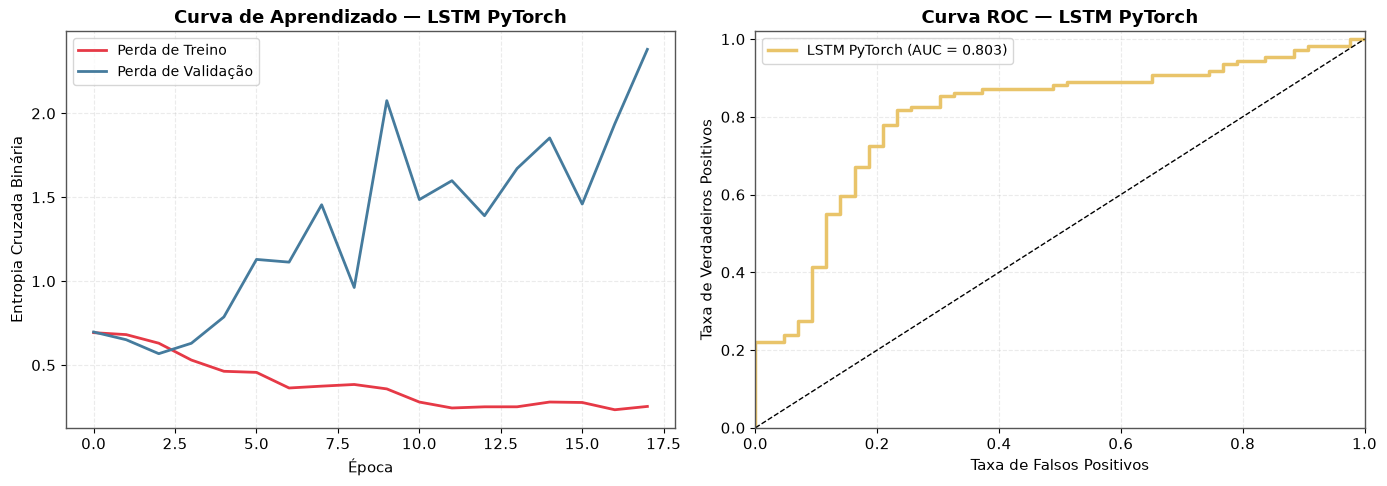


LSTM PyTorch — Resumo:
  Acurácia    : 0.8026
  Precisão    : 0.8990
  Recall      : 0.8165
  F1-Score    : 0.8558
  ROC-AUC     : 0.8026


In [30]:
# Avaliação do LSTM PyTorch
modelo_pt.eval()
with torch.no_grad():
    y_prob_lstm_pt = modelo_pt(X_teste_tensor).cpu().numpy()

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].plot(perdas_treino_pt,    color=PALETA[0], linewidth=2, label='Perda de Treino')
eixos[0].plot(perdas_val_pt, color=PALETA[1], linewidth=2, label='Perda de Validação')
eixos[0].set_title('Curva de Aprendizado — LSTM PyTorch', fontweight='bold')
eixos[0].set_xlabel('Época')
eixos[0].set_ylabel('Entropia Cruzada Binária')
eixos[0].legend()

if len(np.unique(y_seq_teste)) > 1:
    fpr_pt, tpr_pt, limiares_pt = roc_curve(y_seq_teste, y_prob_lstm_pt)
    J_pt = tpr_pt - fpr_pt
    limiar_otimo_pt = limiares_pt[np.argmax(J_pt)]
    roc_lstm_pt     = roc_auc_score(y_seq_teste, y_prob_lstm_pt)
    eixos[1].plot(fpr_pt, tpr_pt, color=PALETA[3], linewidth=2.5,
                  label=f'LSTM PyTorch (AUC = {roc_lstm_pt:.3f})')
    eixos[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
else:
    limiar_otimo_pt = 0.5
    roc_lstm_pt     = float('nan')

eixos[1].set_xlim([0, 1]); eixos[1].set_ylim([0, 1.02])
eixos[1].set_title('Curva ROC — LSTM PyTorch', fontweight='bold')
eixos[1].set_xlabel('Taxa de Falsos Positivos')
eixos[1].set_ylabel('Taxa de Verdadeiros Positivos')
eixos[1].legend()

plt.tight_layout()
plt.savefig('avaliacao_lstm_pytorch.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_lstm_pt   = (y_prob_lstm_pt >= limiar_otimo_pt).astype(int)
metricas_lstm_pt = avaliar_classificador(y_seq_teste, y_pred_lstm_pt, y_prob_lstm_pt, 'LSTM (PyTorch)')
metricas_lstm_pt['ROC-AUC'] = roc_lstm_pt

print(f"\nLSTM PyTorch — Resumo:")
for k, v in metricas_lstm_pt.items():
    if k != 'modelo':
        print(f'  {k:<12}: {v:.4f}')

---
## 8. Regressão: Previsão do Número de Casos

Além da classificação binária (surto/normal), treinamos um **Random Forest para Regressão** que prevê diretamente o **número de casos de dengue** 16 semanas à frente.

Isso complementa o modelo de classificação, pois permite entender a **magnitude esperada** do surto, não apenas se ele ocorrerá ou não.

**Métricas de regressão:**
- **RMSE**: erro quadrático médio (penaliza erros grandes)
- **MAE**: erro absoluto médio (interpretação direta em casos/semana)
- **R²**: coeficiente de determinação (proporção da variância explicada)

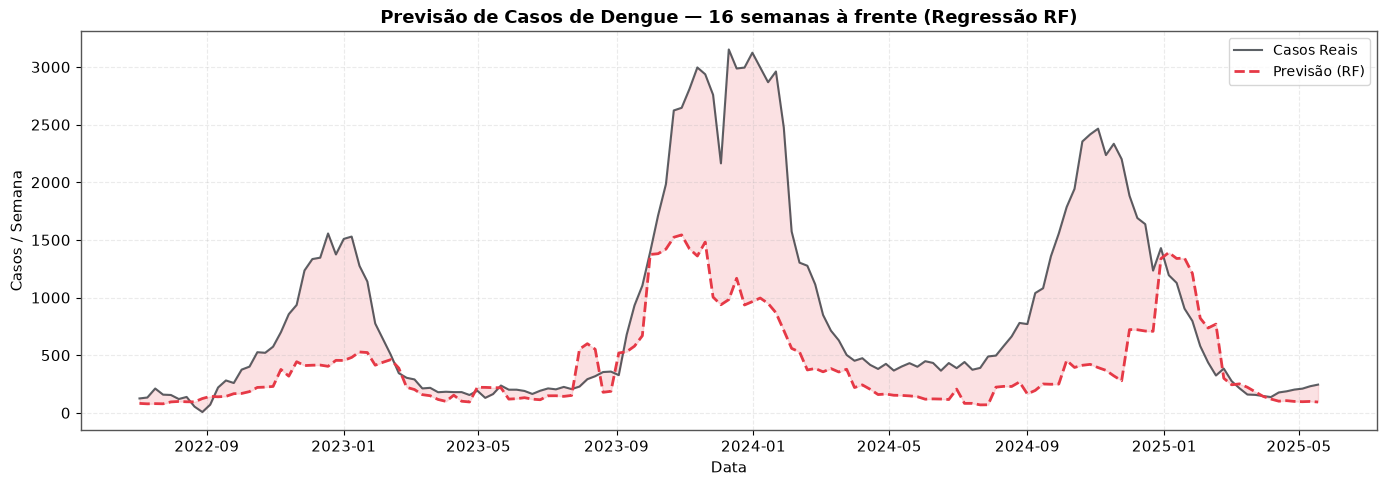


Regressão Random Forest — 16 semanas à frente:
  RMSE : 805.5 casos/semana
  MAE  : 531.4 casos/semana
  R²   : 0.1350


In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

fe_limpo['casos_futuros'] = fe_limpo[COLUNA_ALVO].shift(-HORIZONTE_PREDICAO)
df_regressao = fe_limpo.dropna(subset=['casos_futuros']).copy()

X_reg = df_regressao[colunas_features].ffill().bfill().fillna(0)
y_reg = df_regressao['casos_futuros'].values

divisao_reg = int(len(X_reg) * 0.80)
X_reg_treino = X_reg.iloc[:divisao_reg]
X_reg_teste  = X_reg.iloc[divisao_reg:]
y_reg_treino = y_reg[:divisao_reg]
y_reg_teste  = y_reg[divisao_reg:]

rf_regressao = RandomForestRegressor(
    n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_regressao.fit(X_reg_treino, y_reg_treino)
y_reg_previsto = rf_regressao.predict(X_reg_teste)

rmse = np.sqrt(mean_squared_error(y_reg_teste, y_reg_previsto))
mae  = mean_absolute_error(y_reg_teste, y_reg_previsto)
r2   = rf_regressao.score(X_reg_teste, y_reg_teste)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_regressao.index[divisao_reg:], y_reg_teste,
        color='#343a40', linewidth=1.5, alpha=0.8, label='Casos Reais')
ax.plot(df_regressao.index[divisao_reg:], y_reg_previsto,
        color=PALETA[0], linewidth=2, linestyle='--', label='Previsão (RF)')
ax.fill_between(df_regressao.index[divisao_reg:], y_reg_teste, y_reg_previsto,
                alpha=0.15, color=PALETA[0])
ax.set_title(f'Previsão de Casos de Dengue — {HORIZONTE_PREDICAO} semanas à frente (Regressão RF)',
             fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Casos / Semana')
ax.legend()

plt.tight_layout()
plt.savefig('previsao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nRegressão Random Forest — {HORIZONTE_PREDICAO} semanas à frente:')
print(f'  RMSE : {rmse:.1f} casos/semana')
print(f'  MAE  : {mae:.1f} casos/semana')
print(f'  R²   : {r2:.4f}')

---
## 9. Comparação Final dos Modelos

Aqui consolidamos todas as métricas de classificação e geramos um gráfico comparativo entre:
- Random Forest Baseline
- Random Forest Otimizado (GridSearchCV)
- LSTM NumPy (implementação manual)
- LSTM PyTorch (backpropagation completo)

### Interpretação das métricas:
- **Acurácia**: percentual total de acertos (não é a melhor métrica para dados desbalanceados)
- **Precisão**: dos surtos previstos, quantos eram reais (reduz alarmes falsos)
- **Recall**: dos surtos reais, quantos foram detectados (crucial para saúde pública)
- **F1-Score**: média harmônica entre Precisão e Recall
- **ROC-AUC**: capacidade de discriminação entre surto e não-surto (métrica principal)

> ⚠️ Em previsão de surtos, **Recall** costuma ser mais importante que Precisão — é melhor um alarme falso do que perder um surto real.

In [32]:
# Consolidação de todas as métricas
metricas_baseline = {
    'modelo'   : 'Random Forest (Baseline)',
    'Acurácia' : accuracy_score(y_teste, y_pred_baseline),
    'Precisão' : precision_score(y_teste, y_pred_baseline, zero_division=0),
    'Recall'   : recall_score(y_teste, y_pred_baseline, zero_division=0),
    'F1-Score' : f1_score(y_teste, y_pred_baseline, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_teste, y_prob_baseline) if len(np.unique(y_teste)) > 1 else np.nan,
}

todas_metricas = [metricas_baseline, metricas_rf, metricas_lstm_numpy, metricas_lstm_pt]

df_comparacao = pd.DataFrame(todas_metricas).set_index('modelo')

print('=' * 65)
print('COMPARAÇÃO FINAL DOS MODELOS')
print('=' * 65)
print(df_comparacao.to_string(float_format='{:.4f}'.format))
print('=' * 65)

# Destaque do melhor modelo por ROC-AUC
melhor_modelo = df_comparacao['ROC-AUC'].idxmax()
print(f'\n🏆 Melhor modelo por ROC-AUC: {melhor_modelo} ({df_comparacao["ROC-AUC"].max():.4f})')

COMPARAÇÃO FINAL DOS MODELOS
                           Acurácia  Precisão  Recall  F1-Score  ROC-AUC
modelo                                                                  
Random Forest (Baseline)     0.3571    0.6923  0.1651    0.2667   0.4194
Random Forest (Otimizado)    0.3701    0.7143  0.1835    0.2920   0.4135
LSTM (NumPy)                 0.4934    0.8333  0.3670    0.5096   0.5989
LSTM (PyTorch)               0.8026    0.8990  0.8165    0.8558   0.8026

🏆 Melhor modelo por ROC-AUC: LSTM (PyTorch) (0.8026)


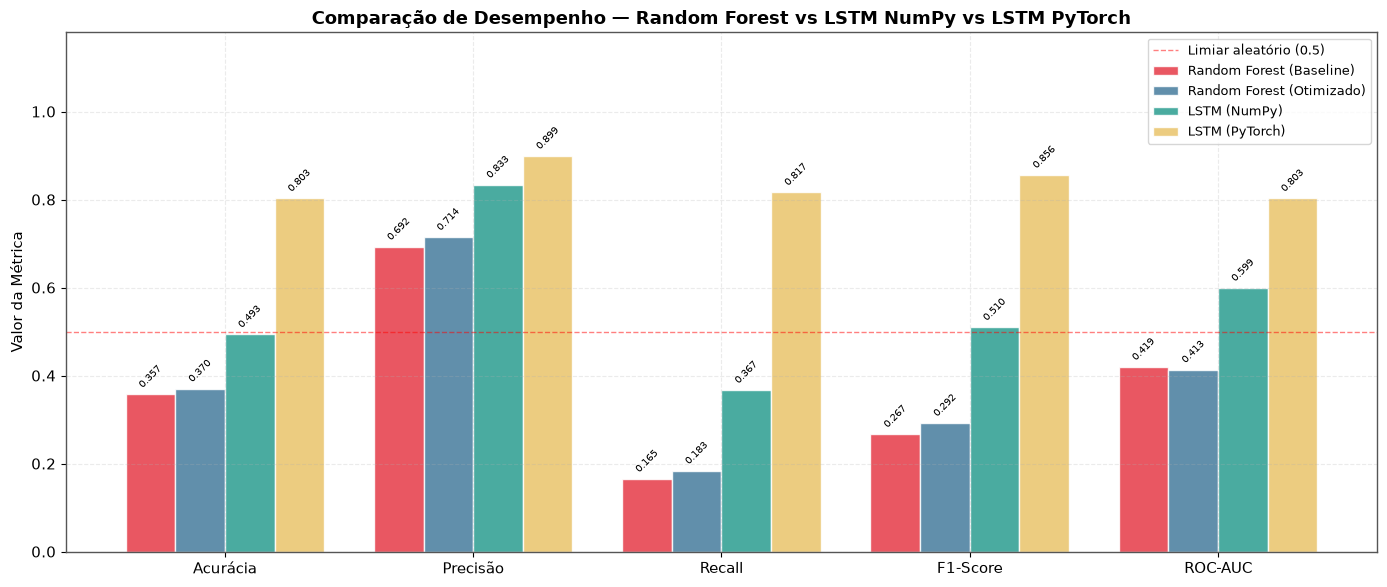

In [33]:
# Gráfico comparativo de barras
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_comparacao.columns))
largura = 0.20
cores_barras = PALETA_CORES[:len(df_comparacao)]

for i, (nome_modelo, linha) in enumerate(df_comparacao.iterrows()):
    valores = linha.values.astype(float)
    barras = ax.bar(
        x + i * largura, valores, largura,
        label=nome_modelo, color=cores_barras[i], alpha=0.85, edgecolor='white'
    )
    for barra, val in zip(barras, valores):
        if not np.isnan(val):
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45
            )

ax.set_xticks(x + largura * 1.5)
ax.set_xticklabels(df_comparacao.columns)
ax.set_ylim(0, 1.18)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Limiar aleatório (0.5)')
ax.set_title('Comparação de Desempenho — Random Forest vs LSTM NumPy vs LSTM PyTorch',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Valor da Métrica')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

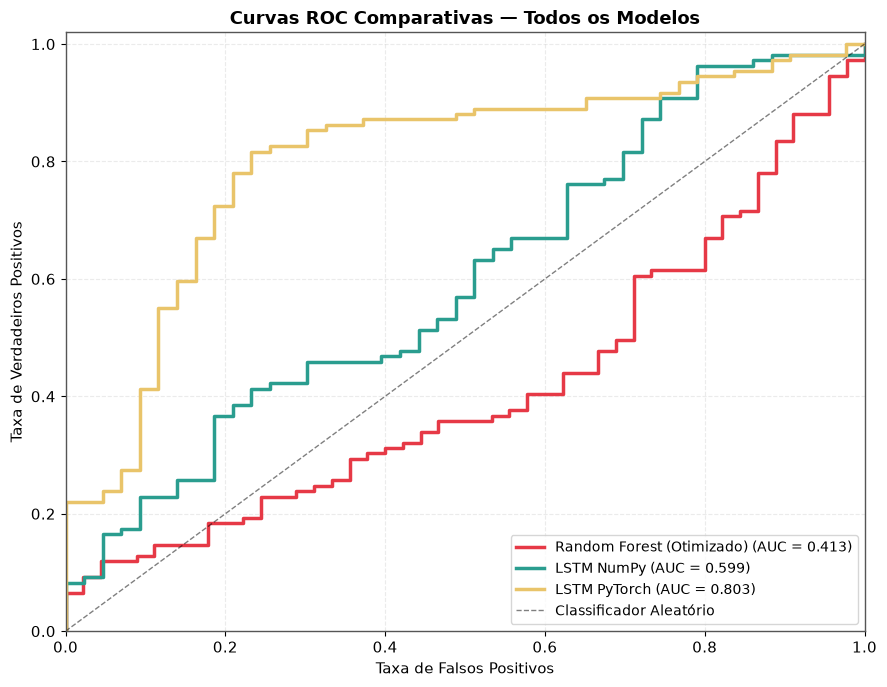

In [34]:
# Curvas ROC sobrepostas para comparação visual
fig, ax = plt.subplots(figsize=(9, 7))

pares_avaliacao = [
    (y_teste,     y_prob_rf,         'Random Forest (Otimizado)', PALETA_CORES[0]),
    (y_seq_teste, y_prob_lstm_numpy,  'LSTM NumPy',               PALETA_CORES[2]),
    (y_seq_teste, y_prob_lstm_pt,     'LSTM PyTorch',             PALETA_CORES[3]),
]

for y_v, y_p, rotulo, cor in pares_avaliacao:
    if len(np.unique(y_v)) > 1:
        fpr_c, tpr_c, _ = roc_curve(y_v, y_p)
        auc_c = roc_auc_score(y_v, y_p)
        ax.plot(fpr_c, tpr_c, color=cor, linewidth=2.5, label=f'{rotulo} (AUC = {auc_c:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Classificador Aleatório')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_title('Curvas ROC Comparativas — Todos os Modelos', fontweight='bold')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('roc_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

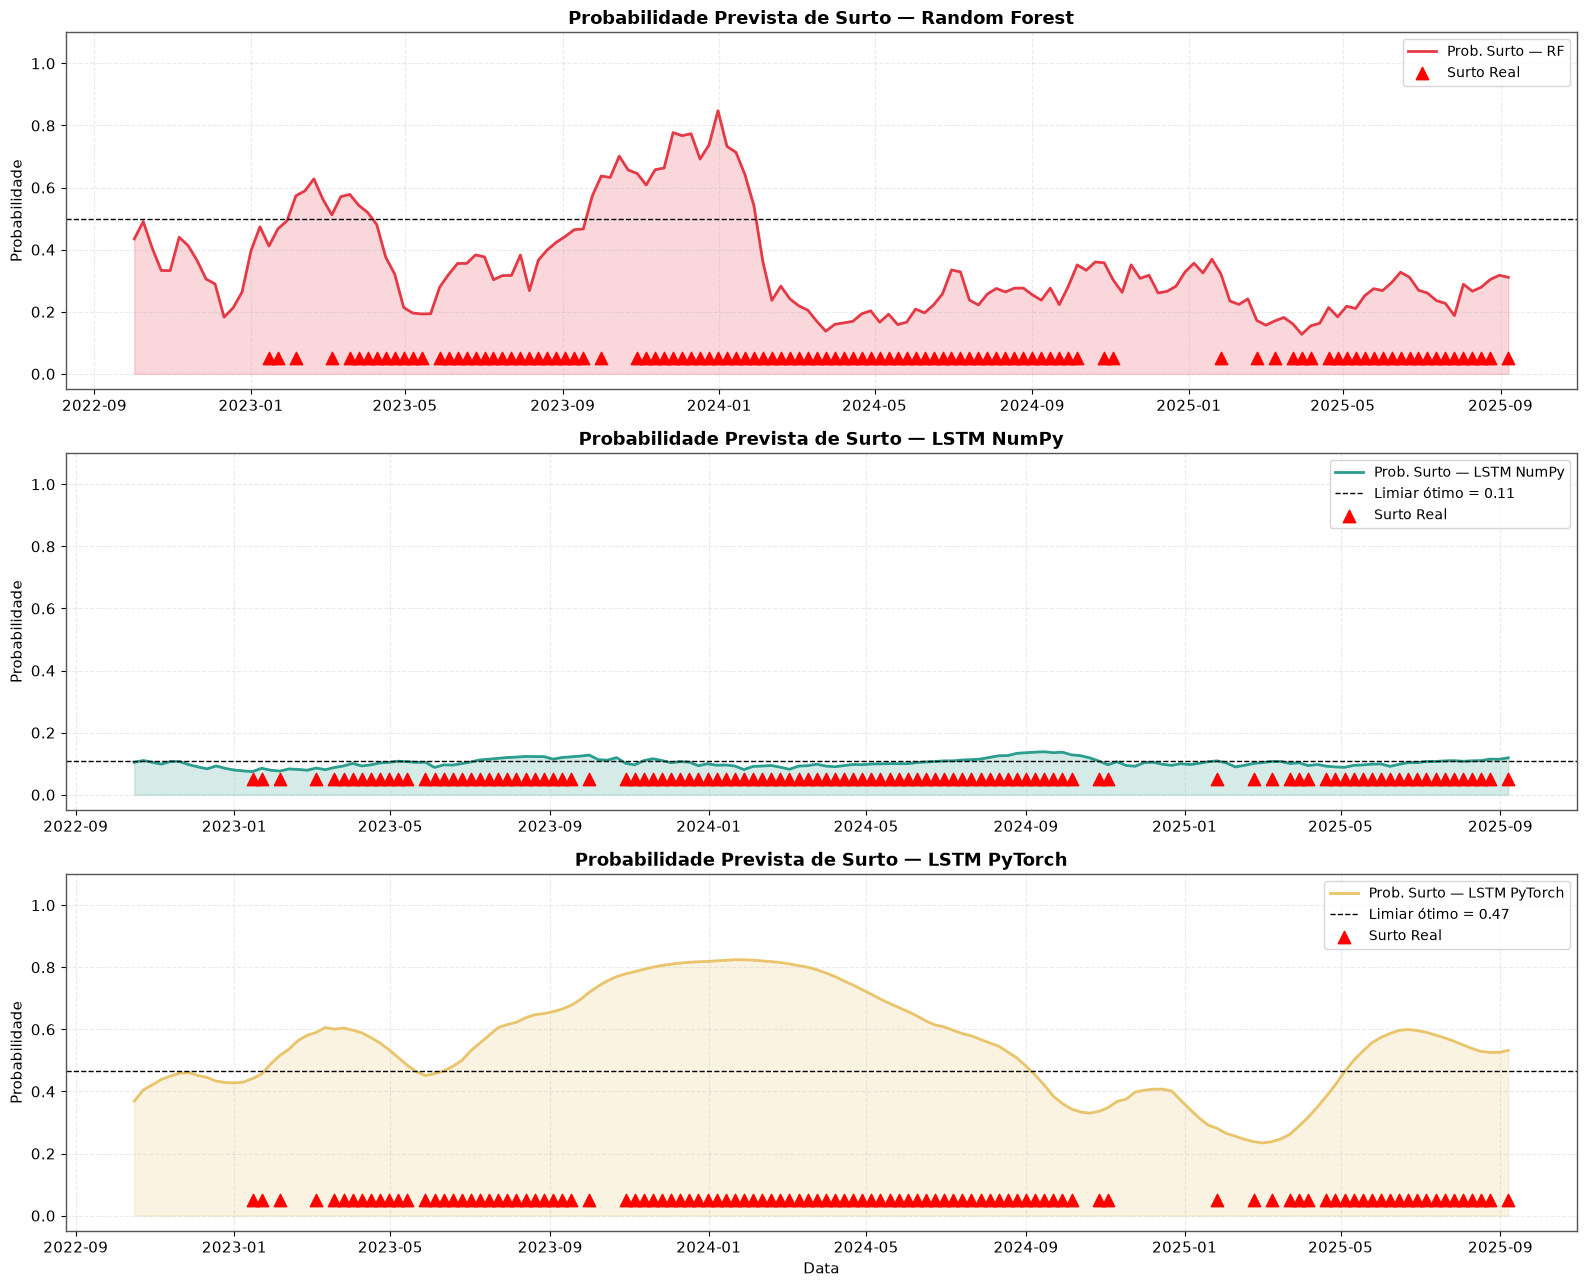

In [35]:
# Linha do tempo das previsões probabilísticas
fig, eixos = plt.subplots(3, 1, figsize=(16, 13), sharex=False)

# --- Random Forest ---
datas_teste_rf = X_teste.index
eixos[0].plot(datas_teste_rf, y_prob_rf, color=PALETA[0], linewidth=2, label='Prob. Surto — RF')
eixos[0].fill_between(datas_teste_rf, 0, y_prob_rf, alpha=0.2, color=PALETA[0])
eixos[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
datas_surto_rf = datas_teste_rf[y_teste == 1]
if len(datas_surto_rf) > 0:
    eixos[0].scatter(datas_surto_rf, [0.05]*len(datas_surto_rf), marker='^', color='red', s=80, zorder=5, label='Surto Real')
eixos[0].set_ylim(-0.05, 1.1)
eixos[0].set_title('Probabilidade Prevista de Surto — Random Forest', fontweight='bold')
eixos[0].set_ylabel('Probabilidade')
eixos[0].legend(loc='upper right')

# --- LSTM NumPy ---
n_teste_lstm = len(y_seq_teste)
datas_teste_lstm = fe_limpo.index[COMPRIMENTO_SEQUENCIA + divisao_seq : COMPRIMENTO_SEQUENCIA + divisao_seq + n_teste_lstm]
if len(datas_teste_lstm) == len(y_prob_lstm_numpy):
    eixos[1].plot(datas_teste_lstm, y_prob_lstm_numpy, color=PALETA[2], linewidth=2, label='Prob. Surto — LSTM NumPy')
    eixos[1].fill_between(datas_teste_lstm, 0, y_prob_lstm_numpy, alpha=0.2, color=PALETA[2])
    eixos[1].axhline(limiar_otimo, color='black', linestyle='--', linewidth=1, label=f'Limiar ótimo = {limiar_otimo:.2f}')
    mascara_surto_numpy = y_seq_teste == 1
    if mascara_surto_numpy.sum() > 0:
        eixos[1].scatter(datas_teste_lstm[mascara_surto_numpy], [0.05]*mascara_surto_numpy.sum(),
                         marker='^', color='red', s=80, zorder=5, label='Surto Real')
else:
    eixos[1].plot(y_prob_lstm_numpy, color=PALETA[2], linewidth=2)
eixos[1].set_ylim(-0.05, 1.1)
eixos[1].set_title('Probabilidade Prevista de Surto — LSTM NumPy', fontweight='bold')
eixos[1].set_ylabel('Probabilidade')
eixos[1].legend(loc='upper right')

# --- LSTM PyTorch ---
if len(datas_teste_lstm) == len(y_prob_lstm_pt):
    eixos[2].plot(datas_teste_lstm, y_prob_lstm_pt, color=PALETA[3], linewidth=2, label='Prob. Surto — LSTM PyTorch')
    eixos[2].fill_between(datas_teste_lstm, 0, y_prob_lstm_pt, alpha=0.2, color=PALETA[3])
    eixos[2].axhline(limiar_otimo_pt, color='black', linestyle='--', linewidth=1, label=f'Limiar ótimo = {limiar_otimo_pt:.2f}')
    if mascara_surto_numpy.sum() > 0:
        eixos[2].scatter(datas_teste_lstm[mascara_surto_numpy], [0.05]*mascara_surto_numpy.sum(),
                         marker='^', color='red', s=80, zorder=5, label='Surto Real')
else:
    eixos[2].plot(y_prob_lstm_pt, color=PALETA[3], linewidth=2)
eixos[2].set_ylim(-0.05, 1.1)
eixos[2].set_title('Probabilidade Prevista de Surto — LSTM PyTorch', fontweight='bold')
eixos[2].set_ylabel('Probabilidade')
eixos[2].set_xlabel('Data')
eixos[2].legend(loc='upper right')

plt.tight_layout()
plt.savefig('linha_tempo_previsoes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Sumário Final

### Resultados de Classificação (previsão de surto 16 semanas à frente)
O gráfico acima compara os quatro modelos. Pontos chave:
- **Random Forest Otimizado** tende a ter maior ROC-AUC por aproveitar o GridSearchCV
- **LSTM PyTorch** usa backpropagation completo, potencialmente capturando dependências temporais mais complexas
- **LSTM NumPy** serve como referência didática e de implementação manual

### Resultado de Regressão (previsão do número de casos)
O Random Forest para Regressão complementa a análise estimando a magnitude dos surtos.

### Próximos passos sugeridos:
- Adicionar features de dados socioeconômicos e de infraestrutura urbana
- Testar arquiteturas mais profundas (Transformer, Seq2Seq)
- Implementar previsão por município/sub-região
- Integrar dados em tempo real para alertas automáticos

In [ ]:
print('\n' + '=' * 65)
print('SUMÁRIO FINAL DE MÉTRICAS DE CLASSIFICAÇÃO')
print('=' * 65)
print(df_comparacao.to_string(float_format='{:.4f}'.format))
print('=' * 65)
print(f'\nMelhor modelo por ROC-AUC : {df_comparacao["ROC-AUC"].idxmax()}')
print(f'Melhor modelo por F1-Score: {df_comparacao["F1-Score"].idxmax()}')
print(f'Melhor modelo por Recall  : {df_comparacao["Recall"].idxmax()}')
print(f'\nRegressão RF — Previsão de Casos ({HORIZONTE_PREDICAO} semanas à frente):')
print(f'  RMSE : {rmse:.1f} casos/semana')
print(f'  MAE  : {mae:.1f} casos/semana')
print(f'  R²   : {r2:.4f}')


SUMÁRIO FINAL DE MÉTRICAS DE CLASSIFICAÇÃO
                           Acurácia  Precisão  Recall  F1-Score  ROC-AUC
modelo                                                                  
Random Forest (Baseline)     0.3571    0.6923  0.1651    0.2667   0.4194
Random Forest (Otimizado)    0.3701    0.7143  0.1835    0.2920   0.4135
LSTM (NumPy)                 0.4934    0.8333  0.3670    0.5096   0.5989
LSTM (PyTorch)               0.8026    0.8990  0.8165    0.8558   0.8026

Melhor modelo por ROC-AUC : LSTM (PyTorch)
Melhor modelo por F1-Score: LSTM (PyTorch)
Melhor modelo por Recall  : LSTM (PyTorch)

Regressão RF — Previsão de Casos (16 semanas à frente):
  RMSE : 805.5 casos/semana
  MAE  : 531.4 casos/semana
  R²   : 0.1350


: 